In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
import math
import re

In [2]:
# Determine the absolute path to the src directory (one level up from notebooks)
module_path = os.path.abspath(os.path.join("..", "src"))
if module_path not in sys.path:
    sys.path.append(module_path)
project_root = os.path.abspath(os.path.join(".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src import utils, analytics, plotting

In [3]:
ROOT_FOLDER = os.path.dirname(os.getcwd())
RUNS_FOLDER = os.path.join(ROOT_FOLDER, "runs")
SINGLE_RUNS_FOLDER = os.path.join(RUNS_FOLDER, "single_runs")
BATCH_RUNS_FOLDER = os.path.join(RUNS_FOLDER, "batch_runs")
TEST_BATCH_RUNS_FOLDER = os.path.join(BATCH_RUNS_FOLDER, "test")

In [4]:
batch_name = "batch_128_4_4_4core_bat_and_no_bat"
batch_folder = os.path.join(BATCH_RUNS_FOLDER, batch_name)

In [5]:
batch_folder = [os.path.join(batch_folder, f) for f in os.listdir(batch_folder)]
print(batch_folder)

['c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\batch_runs\\batch_128_4_4_4core_bat_and_no_bat\\1_May16_Fri_h23_m07_s45-GTSEP_stochastic_v1-128_ES_PT', 'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\batch_runs\\batch_128_4_4_4core_bat_and_no_bat\\2_May17_Sat_h00_m00_s46-GTSEP_stochastic_v1-128_ES_PT_no_bat']


In [6]:
results_folders_to_explore = batch_folder
# display_names = [f"results_{str(i)}" for i in range(len(results_folders_to_explore))]
display_names = ["Base", "No Battery"]
# display_names = test_display_names
MAX_COLUMNS = 2

# Alternatively explore all folders in a batch directory

In [7]:
results_folders_to_explore

['c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\batch_runs\\batch_128_4_4_4core_bat_and_no_bat\\1_May16_Fri_h23_m07_s45-GTSEP_stochastic_v1-128_ES_PT',
 'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\batch_runs\\batch_128_4_4_4core_bat_and_no_bat\\2_May17_Sat_h00_m00_s46-GTSEP_stochastic_v1-128_ES_PT_no_bat']

In [8]:
savefolder = os.path.join(
    ROOT_FOLDER, "data", "for_the_report", "results", "-".join(display_names)
)
os.makedirs(savefolder, exist_ok=True)

In [9]:
tables_folder = os.path.join(savefolder, "tables")
os.makedirs(tables_folder, exist_ok=True)
figures_folder = os.path.join(savefolder, "figures")
os.makedirs(figures_folder, exist_ok=True)

## Figures

Showing: Grid-Related Figures
No images found for Grid-Related Figures.
Showing: Bar Figures
No images found for Bar Figures.
Showing: Battery - General Figures


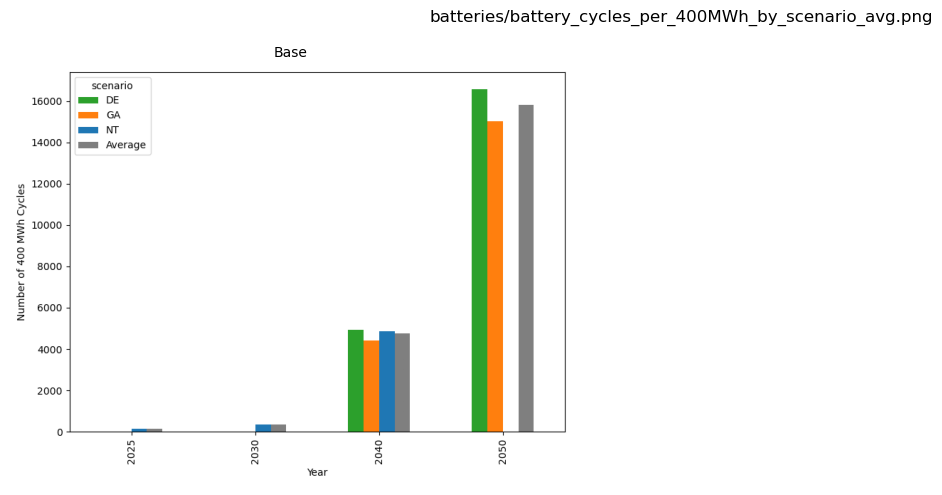

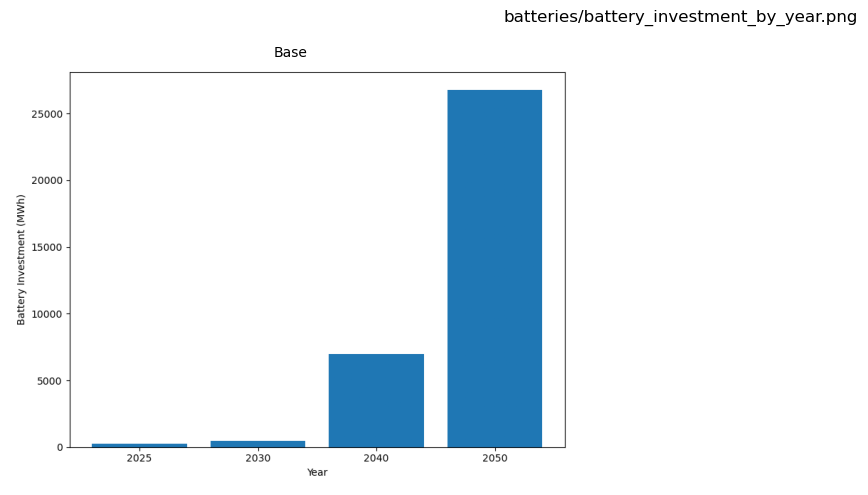

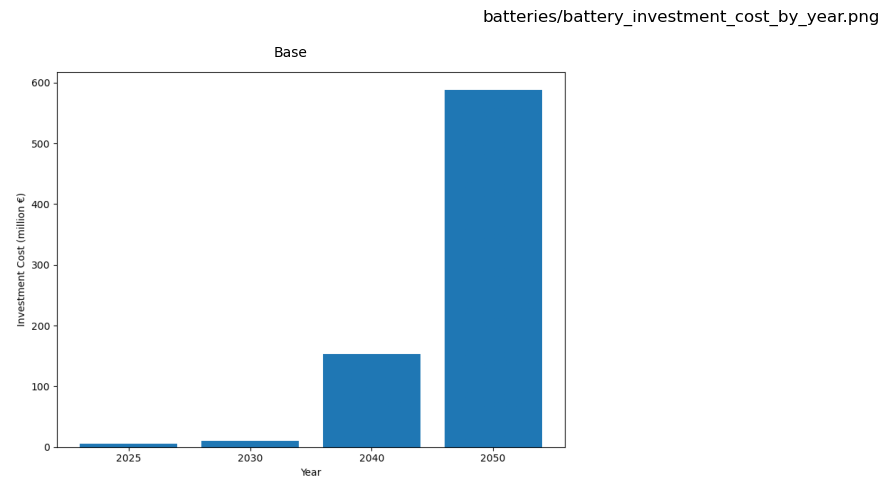

Showing: Remaining Figures


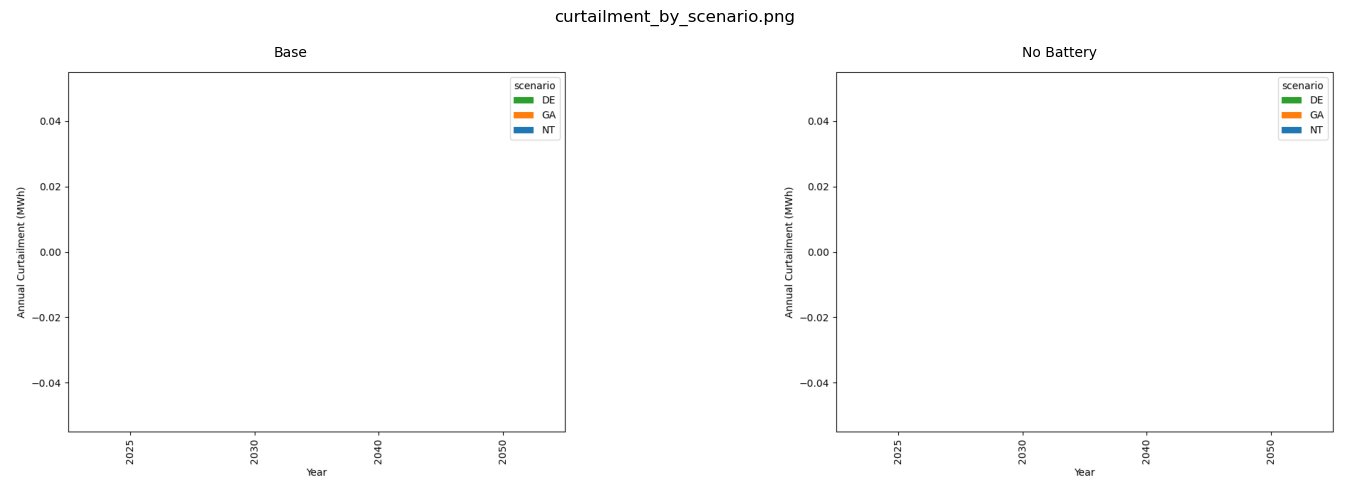

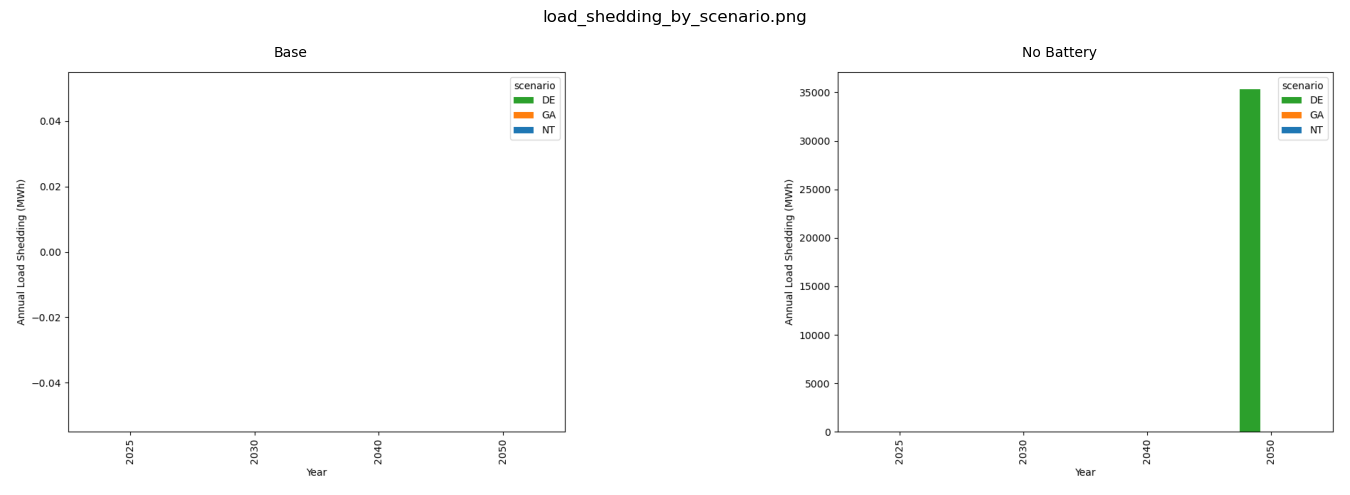

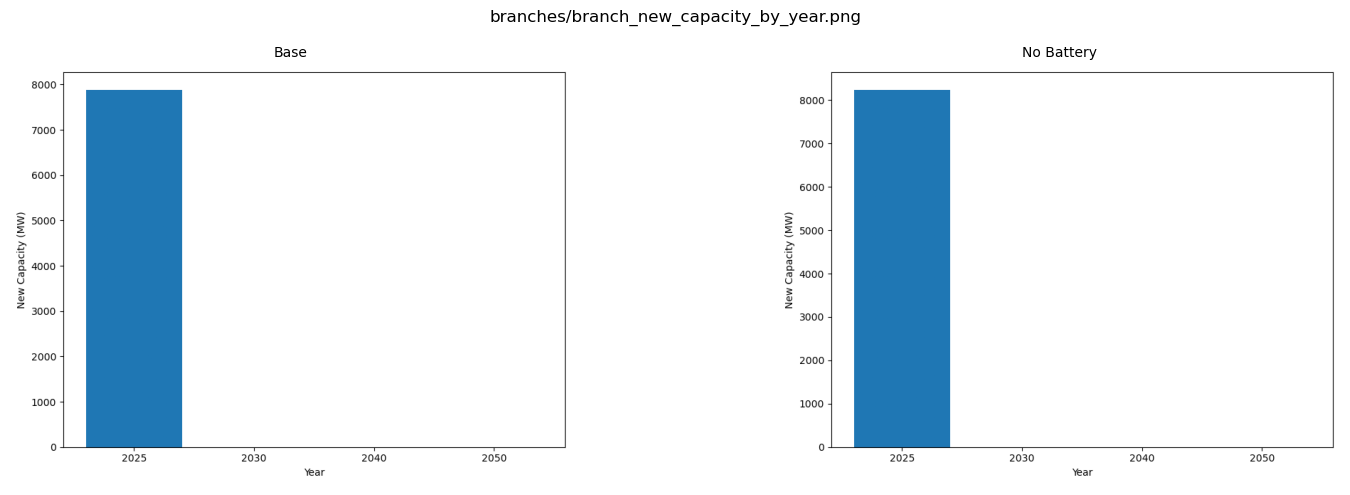

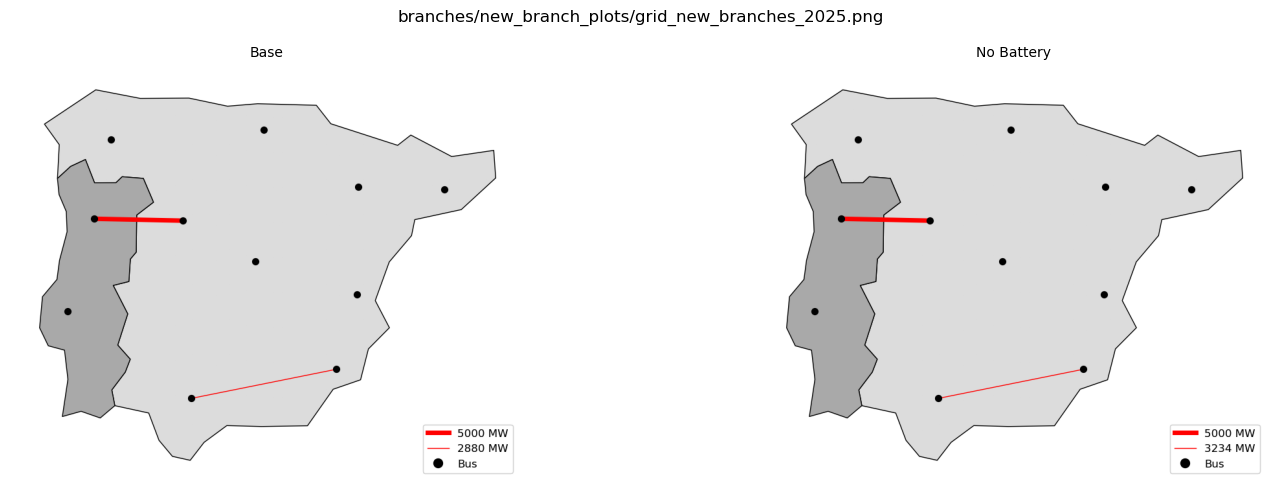

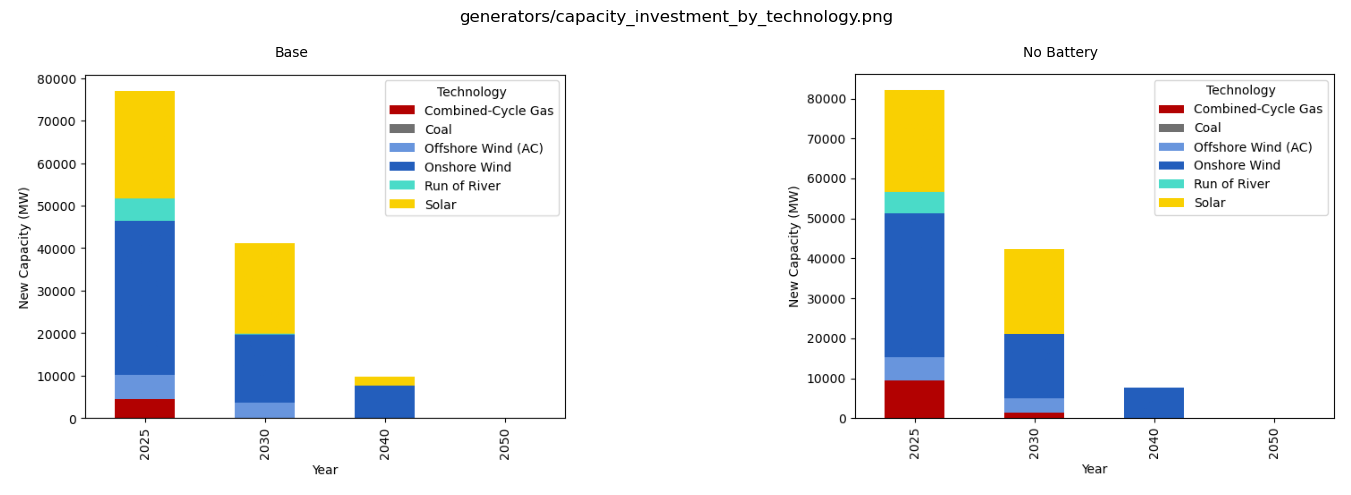

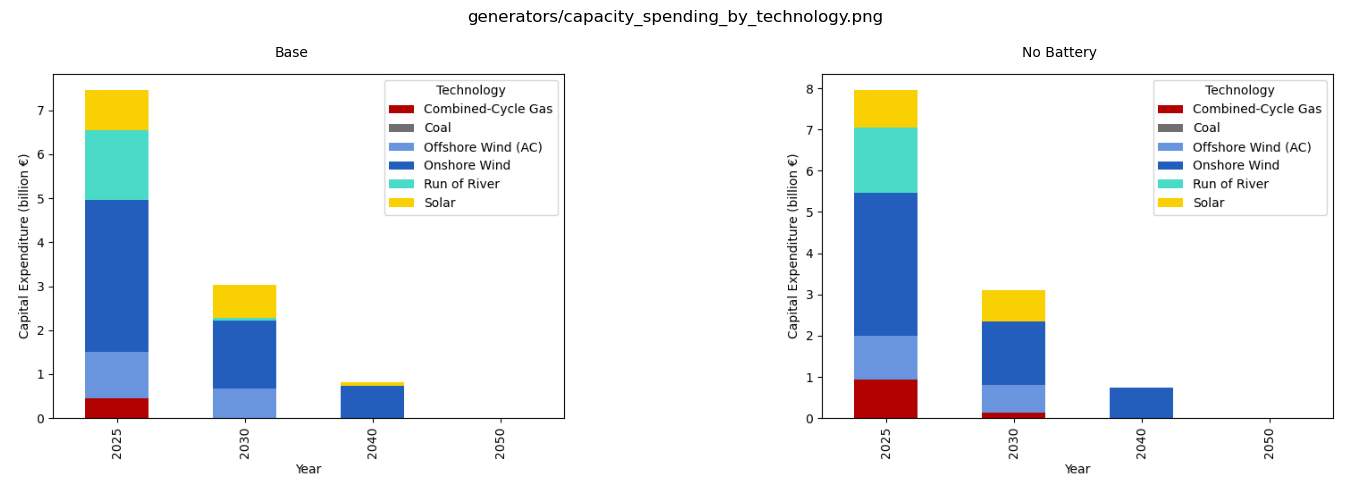

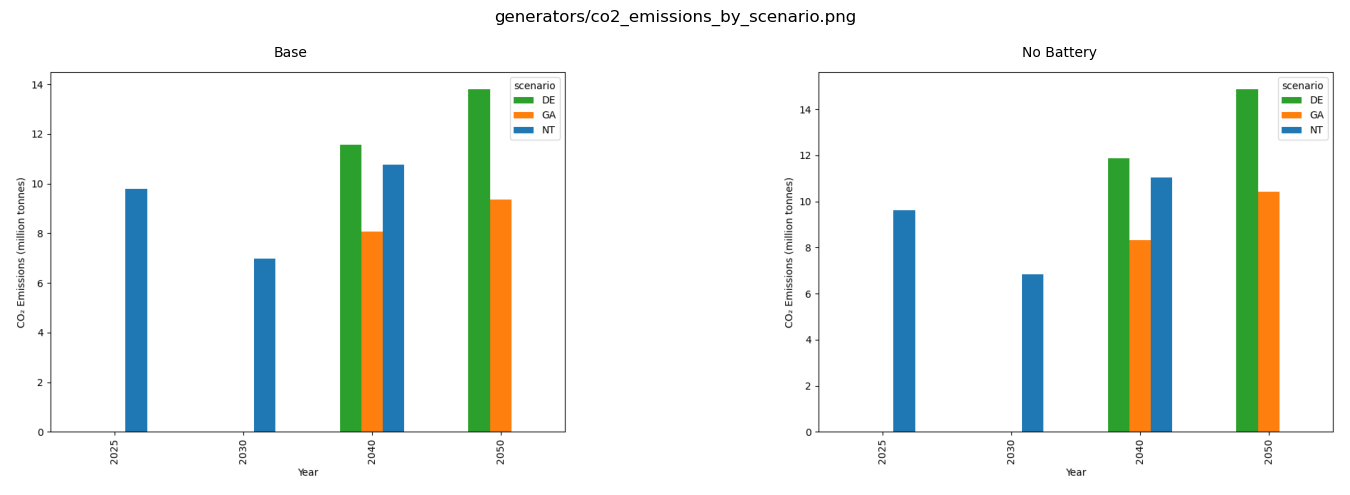

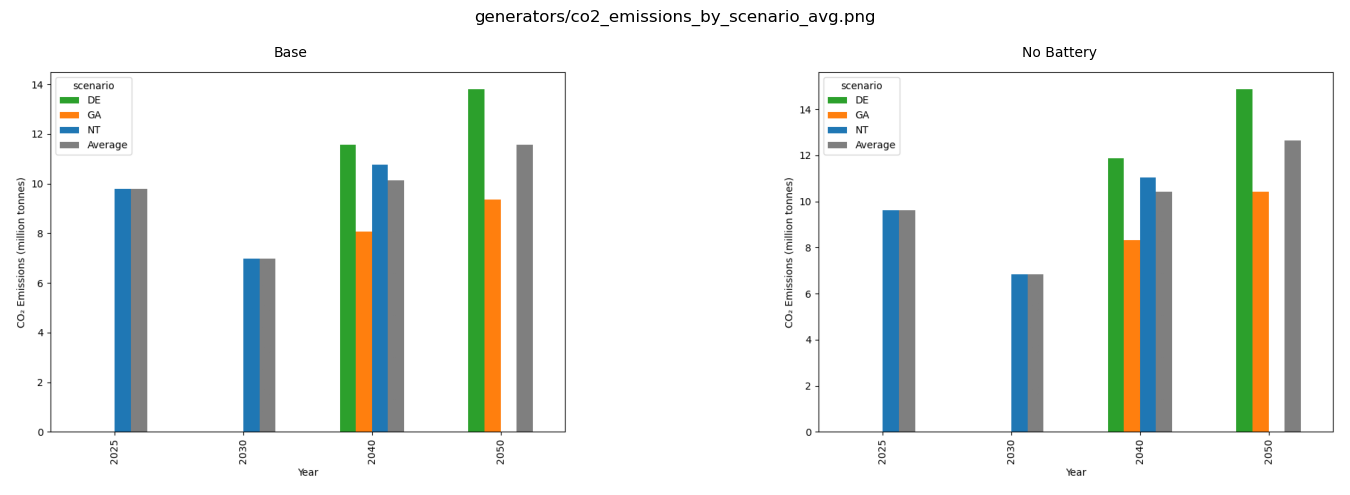

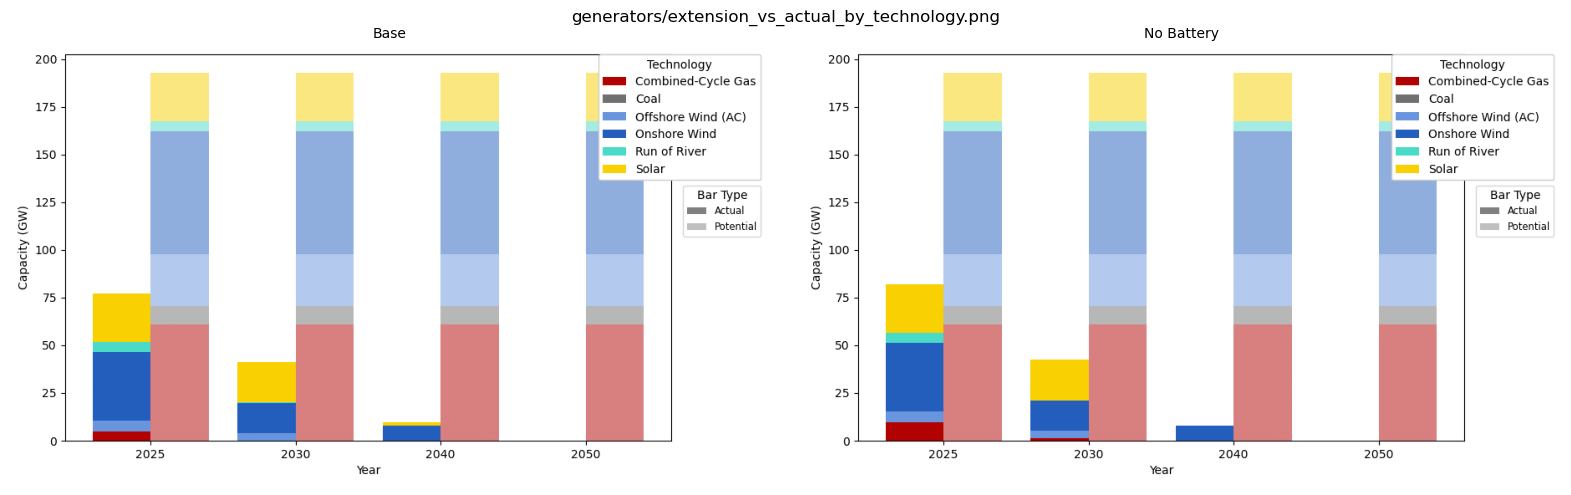

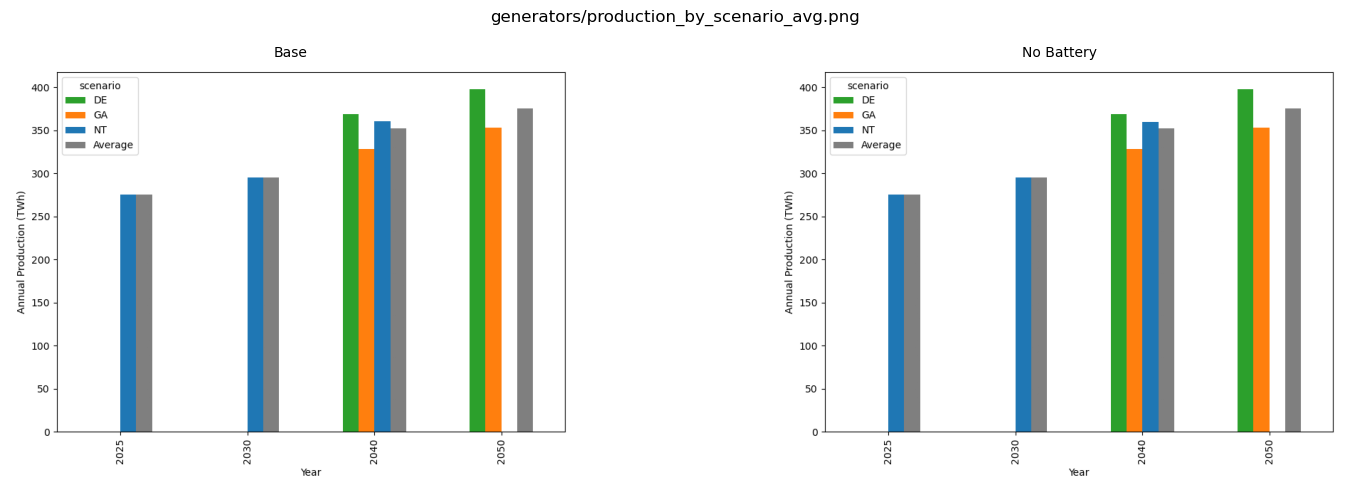

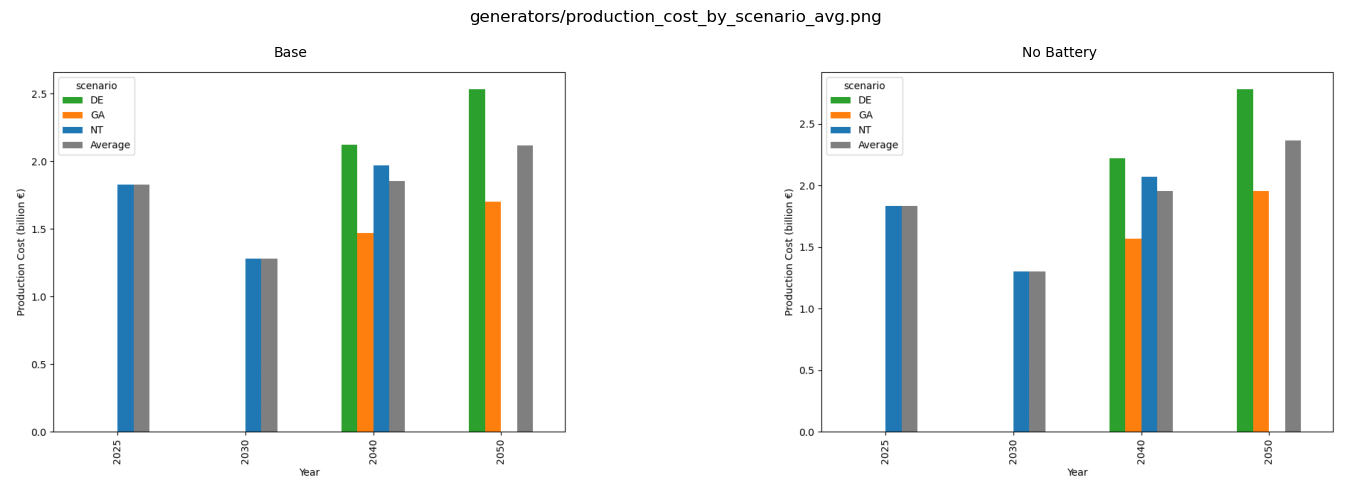

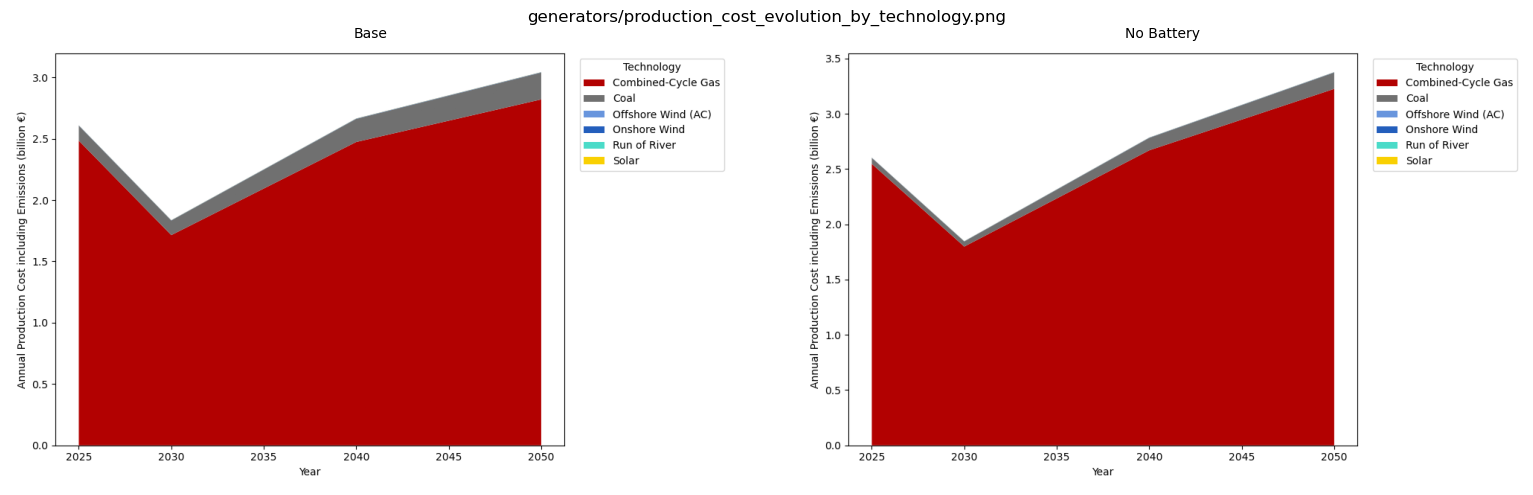

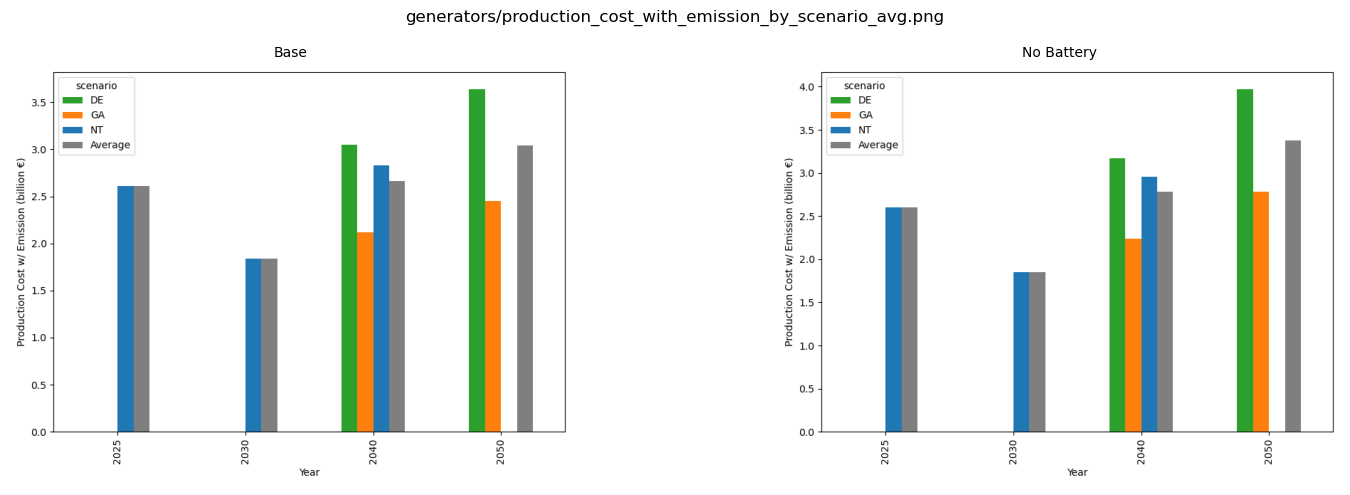

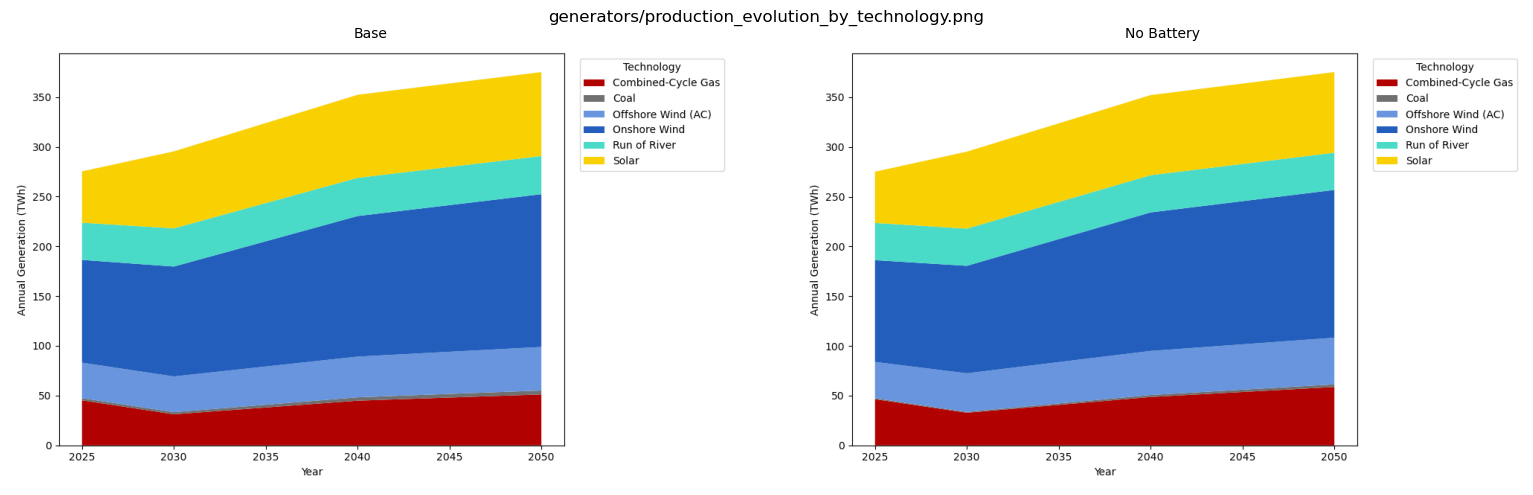

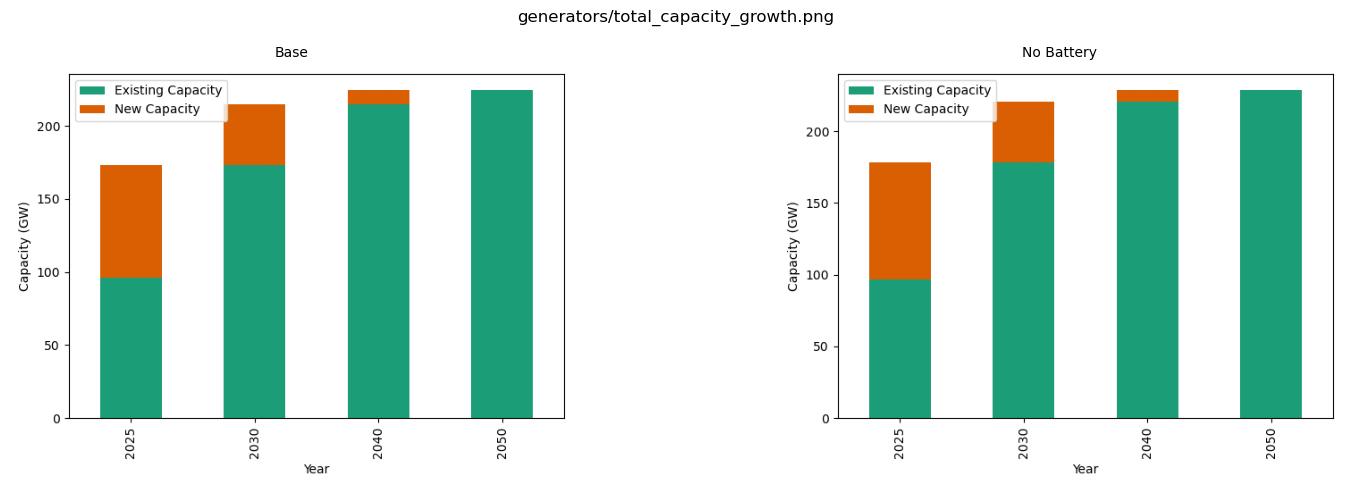

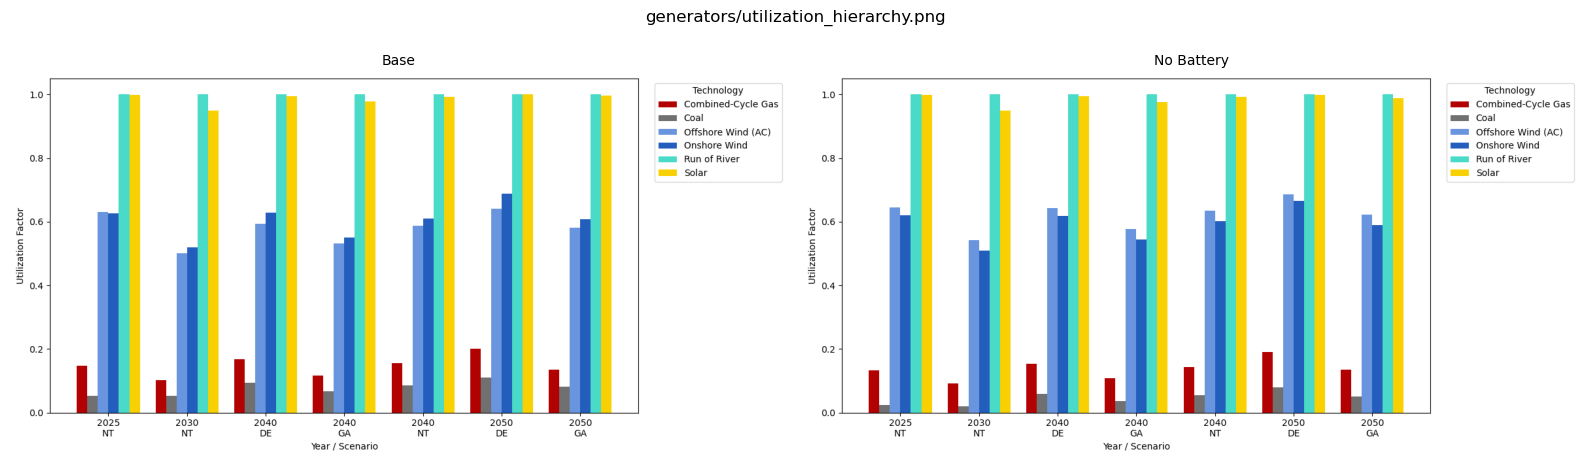

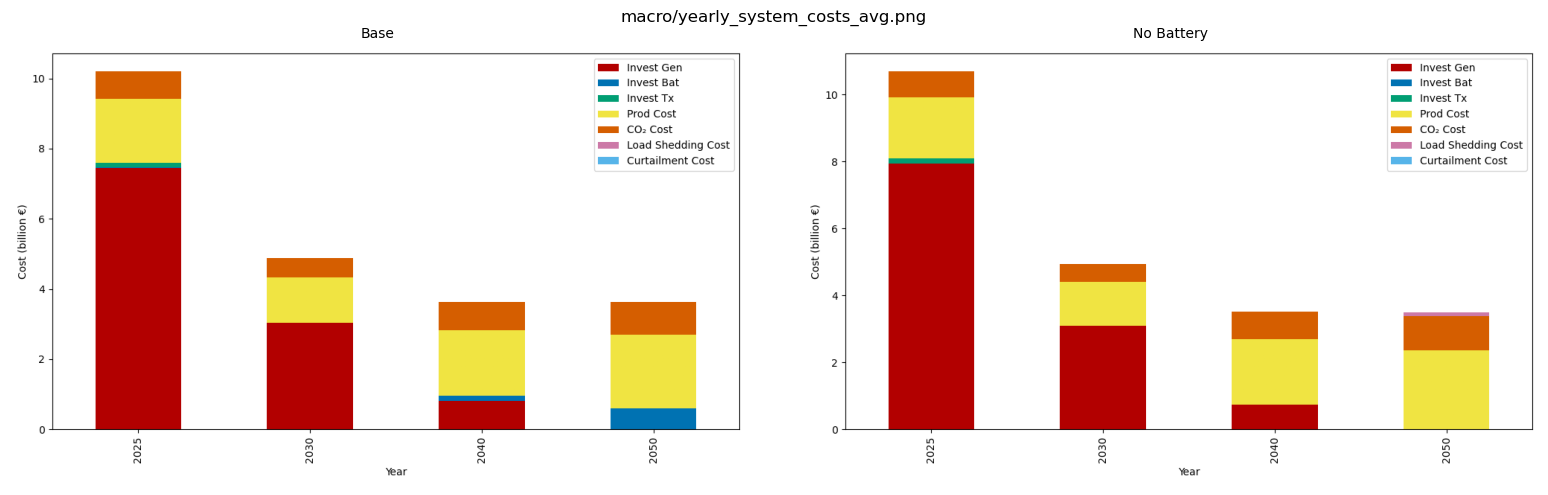

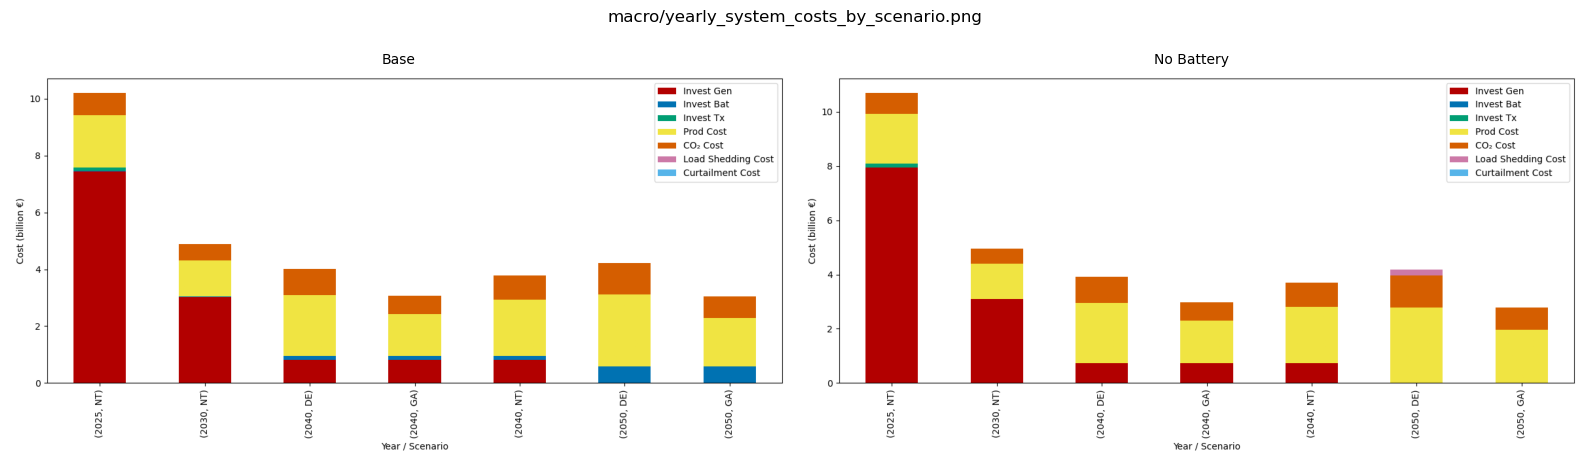

In [10]:
def categorize_png_files(folder):
    figures_path = os.path.join(folder, "results", "figures")
    categorized_files = {
        "grid": [],
        "bar": [],
        "battery_general": [],
        "battery_hourly_soc": [],
        "battery_city_soc": [],
        "remaining": [],
    }

    for root, _, files in os.walk(figures_path):
        for file in files:
            if file.endswith(".png"):
                relative_path = os.path.relpath(os.path.join(root, file), figures_path)

                # Normalize to use forward slashes for regex compatibility
                relative_path = relative_path.replace("\\", "/")

                # Grid figures
                if relative_path.startswith("grid"):
                    categorized_files["grid"].append(relative_path)

                # Bar figures
                elif relative_path.startswith("bar"):
                    categorized_files["bar"].append(relative_path)

                # Battery subfolder
                elif "batteries" in relative_path:
                    if re.match(
                        r"batteries/\d+_plot_battery_average_hourly_soc_month_",
                        relative_path,
                    ):
                        categorized_files["battery_hourly_soc"].append(relative_path)
                    elif re.match(
                        r"batteries/[A-Za-z]+_plot_battery_average_hourly_soc_by_month_",
                        relative_path,
                    ):
                        categorized_files["battery_city_soc"].append(relative_path)
                    else:
                        categorized_files["battery_general"].append(relative_path)

                # Remaining figures
                else:
                    categorized_files["remaining"].append(relative_path)

    return categorized_files


# Get categorized PNG files from the first folder
reference_folder = results_folders_to_explore[0]
png_categories = categorize_png_files(reference_folder)


# Function to display grouped images
def display_images(image_group, title):
    print("=" * 80)
    print(f"Showing: {title}")
    print("=" * 80)

    if not image_group:
        print(f"No images found for {title}.")
        return

    num_folders = len(results_folders_to_explore)
    num_rows = math.ceil(
        num_folders / MAX_COLUMNS
    )  # Dynamically calculate number of rows

    for png_file in image_group:
        fig, axes = plt.subplots(
            num_rows, MAX_COLUMNS, figsize=(8 * MAX_COLUMNS, 5 * num_rows)
        )

        # Ensure axes is always a 2D list for easy indexing
        if num_rows == 1:
            axes = [axes]  # Convert to list of lists for consistency
        if MAX_COLUMNS == 1:
            axes = [
                [ax] for ax in axes
            ]  # Ensure row-based structure if only one column

        # Flatten for easier iteration
        axes = [ax for row in axes for ax in row]

        for idx, (folder, name) in enumerate(
            zip(results_folders_to_explore, display_names)
        ):
            img_path = os.path.join(folder, "results", "figures", png_file)

            if os.path.exists(img_path):
                img = mpimg.imread(img_path)
                axes[idx].imshow(img)
                axes[idx].axis("off")
                axes[idx].set_title(name, fontsize=10)
            else:
                axes[idx].set_visible(False)

        # Hide unused subplots
        for ax in axes[num_folders:]:
            ax.set_visible(False)

        plt.suptitle(png_file, fontsize=12)
        plt.tight_layout()
        plt.show()


# Display images in the correct order
display_images(png_categories["grid"], "Grid-Related Figures")
display_images(png_categories["bar"], "Bar Figures")
display_images(png_categories["battery_general"], "Battery - General Figures")
# display_images(png_categories["battery_hourly_soc"], "Battery - Hourly SOC Figures")
# display_images(png_categories["battery_city_soc"], "Battery - City SOC Figures")
display_images(png_categories["remaining"], "Remaining Figures")

In [11]:
import os
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


def categorize_png_files(
    results_folder: str, section: str = "figures"
) -> dict[str, list[str]]:
    """
    Walk through results/<section> and bucket all .png paths by their top-level category.
    Section can be 'figures' or 'duals'.
    """
    base_path = os.path.join(results_folder, "results", section)
    categories: dict[str, list[str]] = {}
    for root, _, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(".png"):
                full_path = os.path.join(root, file)
                rel_path = os.path.relpath(full_path, base_path)
                parts = rel_path.split(os.sep)
                category = parts[0]  # top-level folder under section
                categories.setdefault(category, []).append(rel_path)
    return categories


def display_images_by_category(
    results_folders: list[str],
    display_names: list[str],
    max_columns: int = 2,
    section: str = "figures",
) -> None:
    """
    For each category of PNGs under results/<section>, display each image side-by-side
    across the given result folders.
    """
    # Discover categories using the first run
    ref = results_folders[0]
    categorized = categorize_png_files(ref, section)

    for category, png_list in categorized.items():
        print("\n" + "=" * 80)
        print(f"Category: {category} (section: {section})")
        print("=" * 80)

        for rel_png in png_list:
            num_runs = len(results_folders)
            cols = min(max_columns, num_runs)
            rows = math.ceil(num_runs / cols)

            fig, axes = plt.subplots(rows, cols, figsize=(8 * cols, 5 * rows))
            # Normalize axes to 2D list
            if isinstance(axes, plt.Axes):
                axes = [[axes]]
            elif rows == 1:
                axes = [axes]
            flat_axes = [ax for row in axes for ax in row]

            for idx, (folder, name) in enumerate(zip(results_folders, display_names)):
                ax = flat_axes[idx]
                img_path = os.path.join(folder, "results", section, rel_png)
                if os.path.exists(img_path):
                    img = mpimg.imread(img_path)
                    ax.imshow(img)
                    ax.axis("off")
                    ax.set_title(name, fontsize=12)
                else:
                    ax.axis("off")

            # Hide any unused subplots
            for ax in flat_axes[num_runs:]:
                ax.axis("off")

            plt.suptitle(rel_png, fontsize=14)
            plt.tight_layout()
            plt.show()
            plt.close()


# Example usage:
# display_images_by_category(results_folders_to_explore, display_names, max_columns=2, section="duals")


Category: curtailment_by_scenario.png (section: figures)


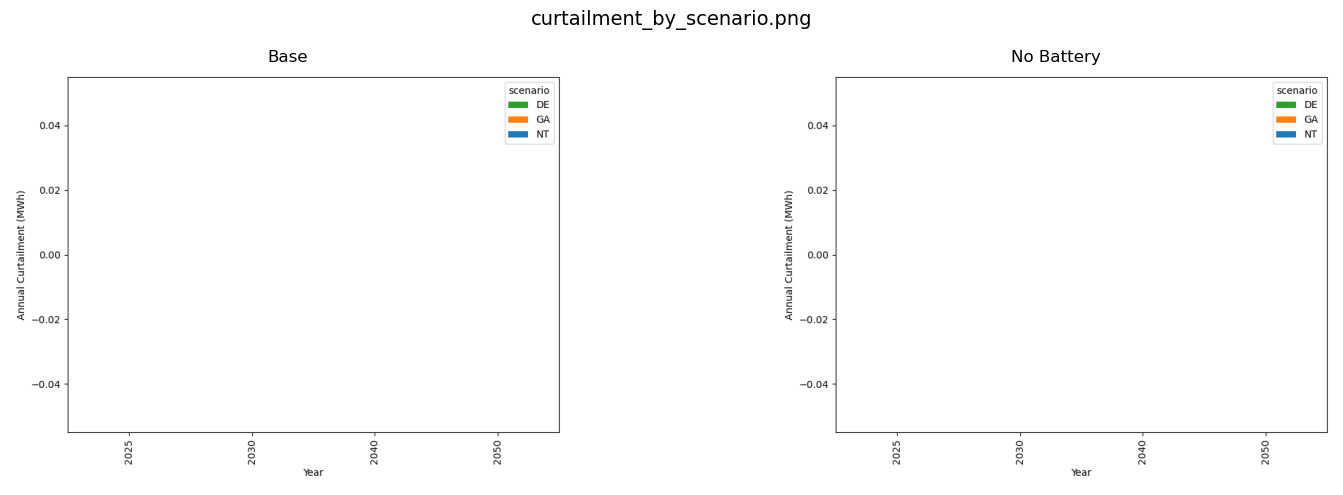


Category: load_shedding_by_scenario.png (section: figures)


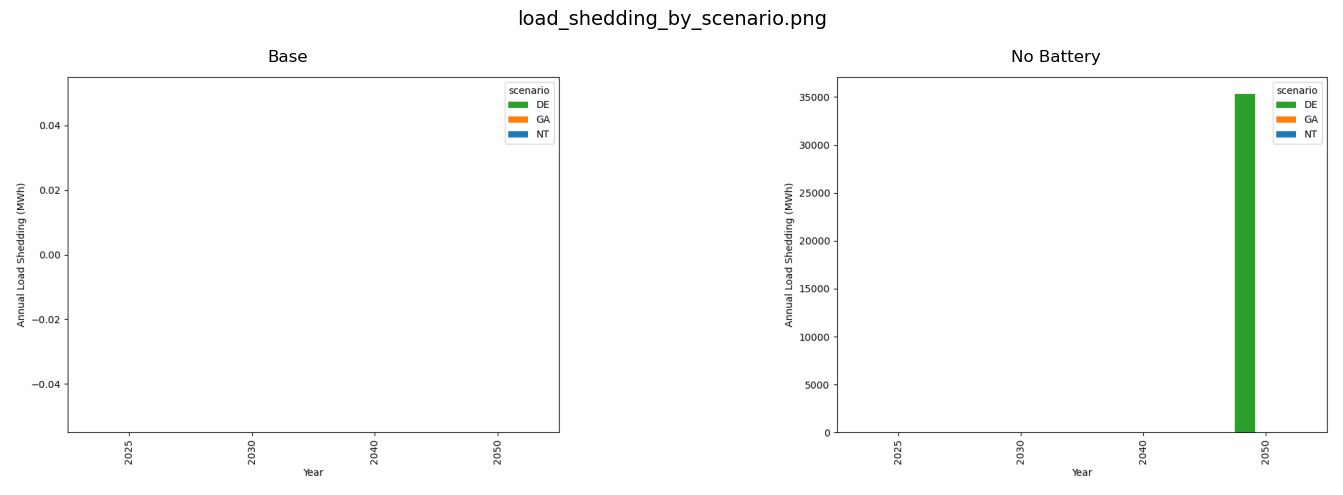


Category: batteries (section: figures)


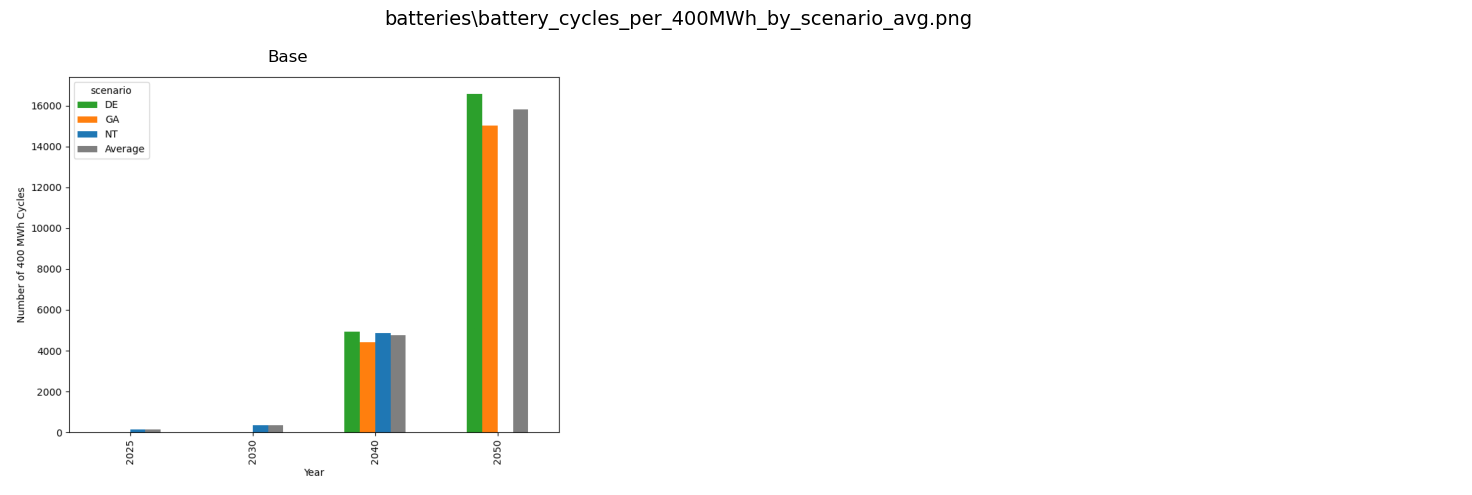

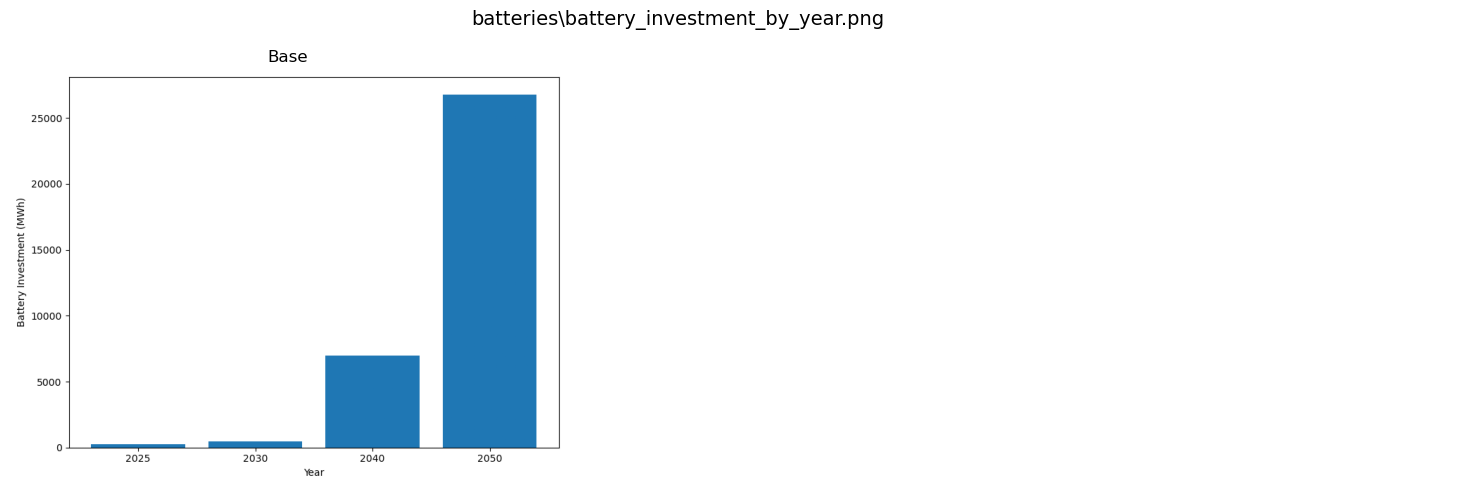

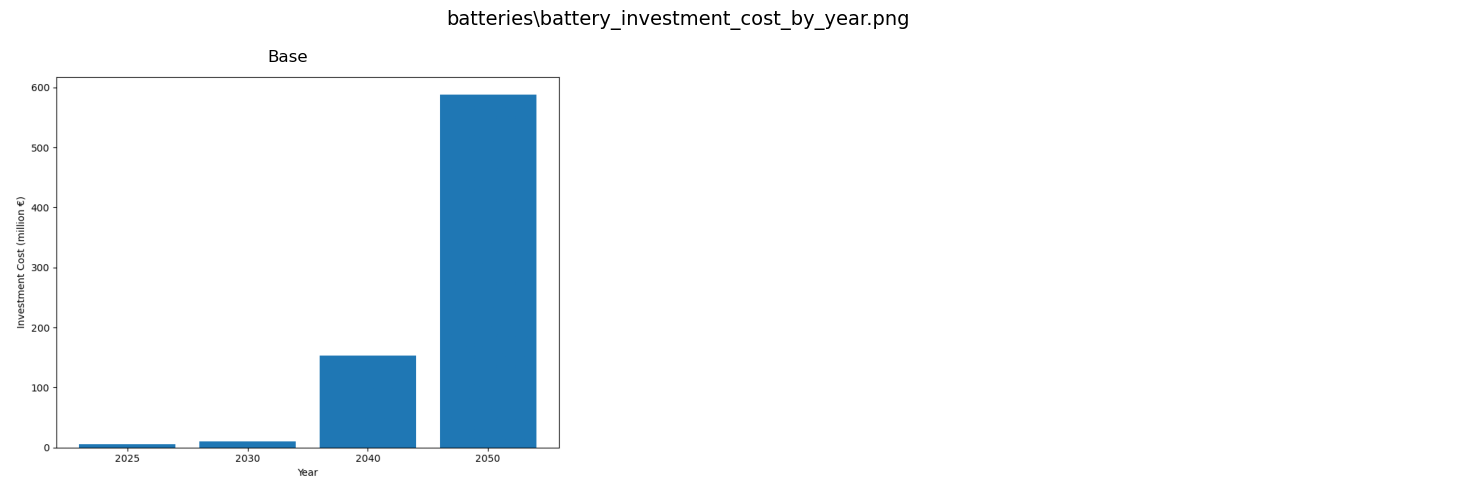


Category: branches (section: figures)


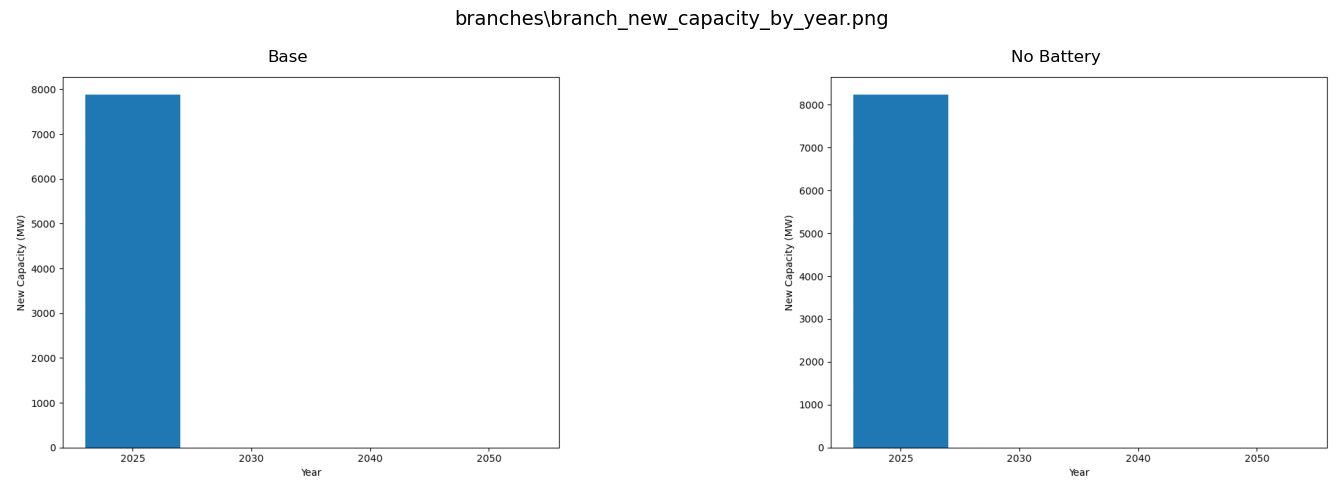

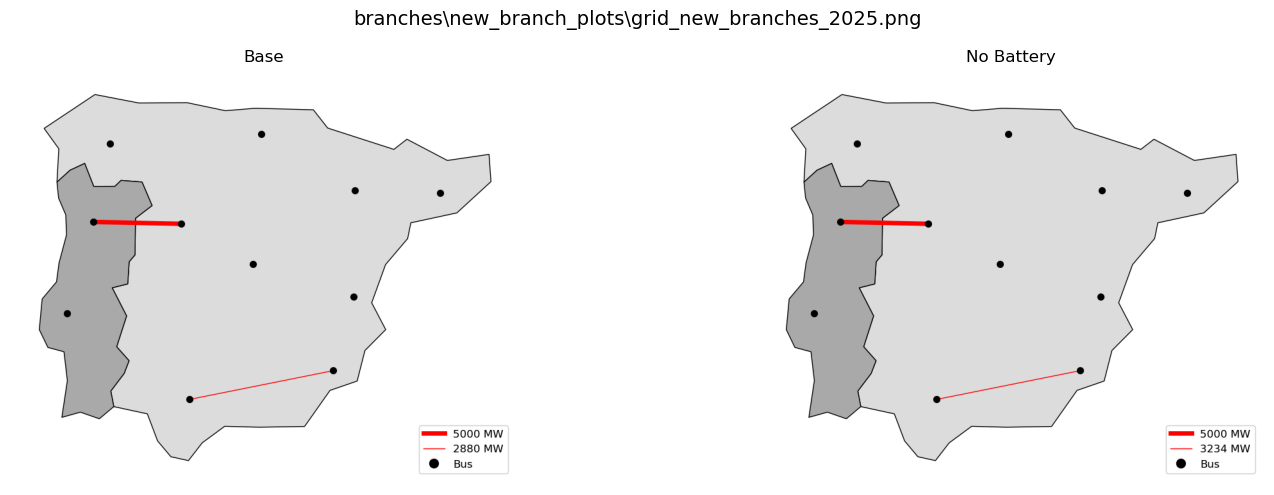


Category: generators (section: figures)


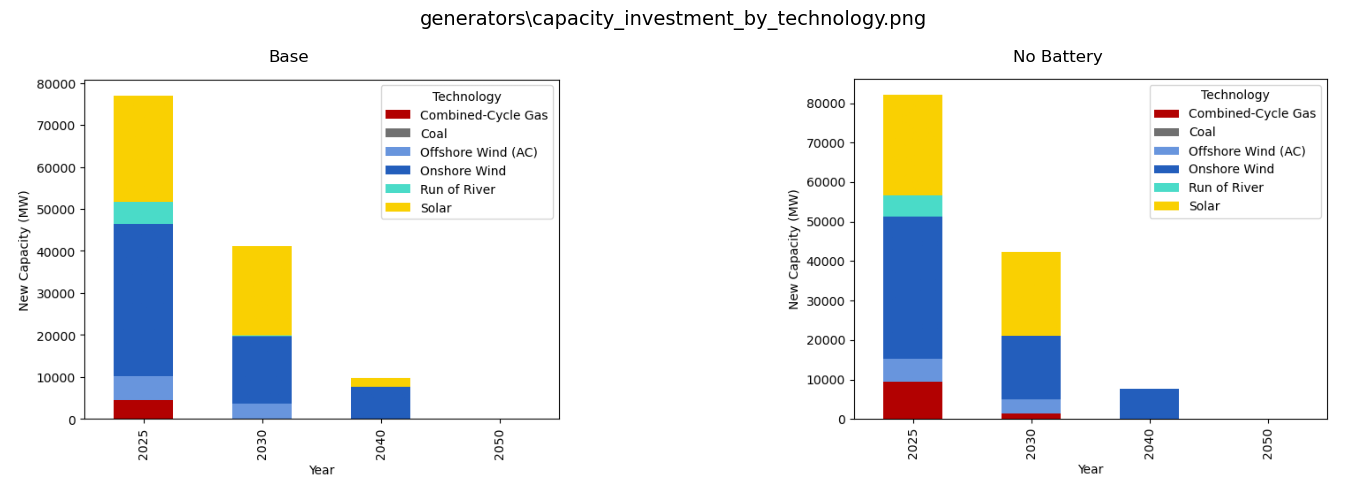

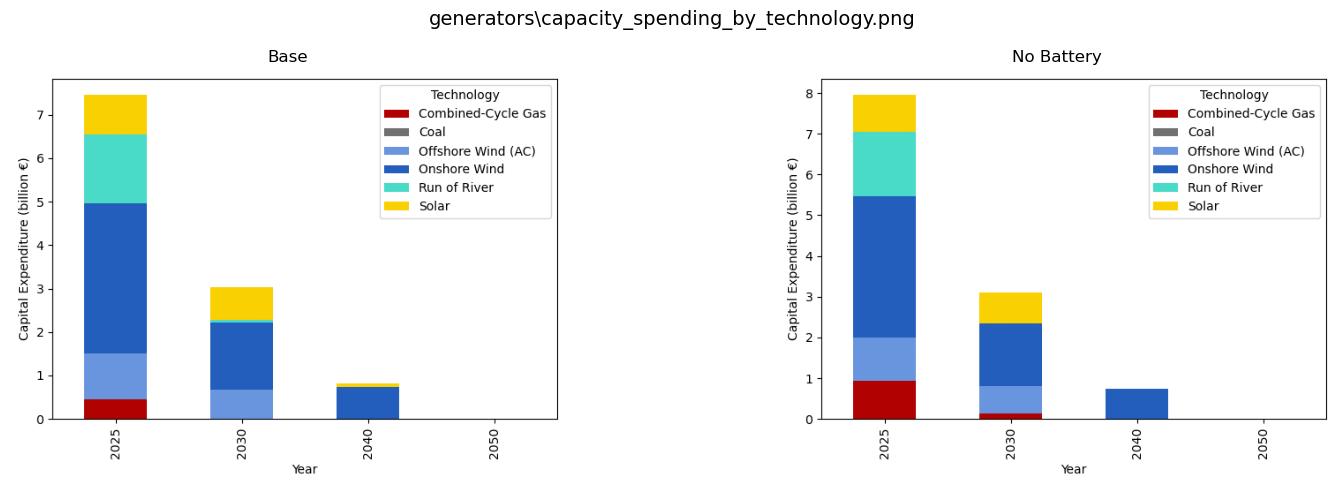

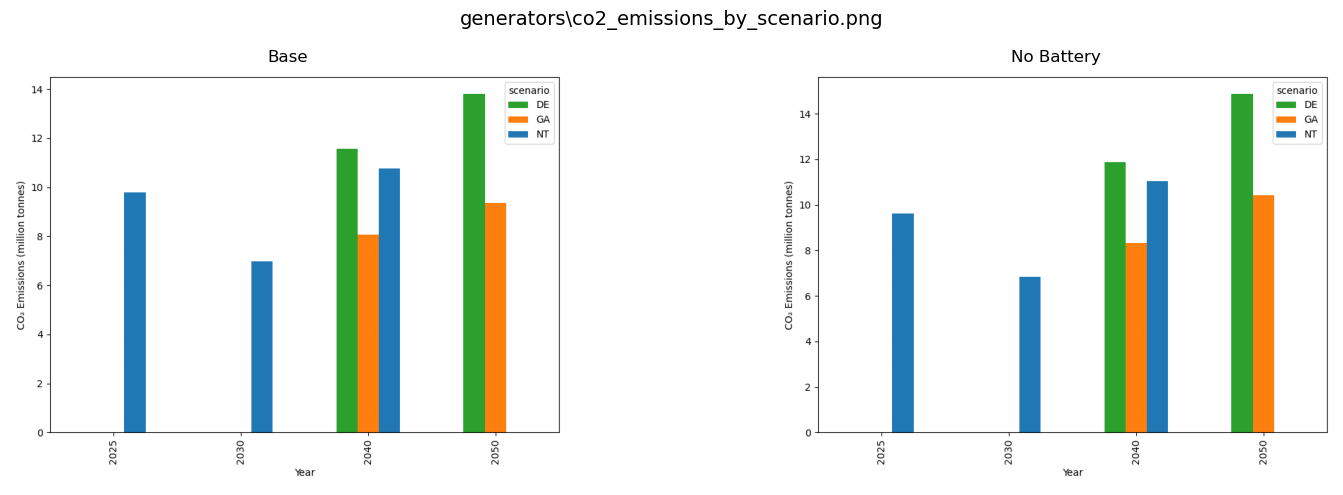

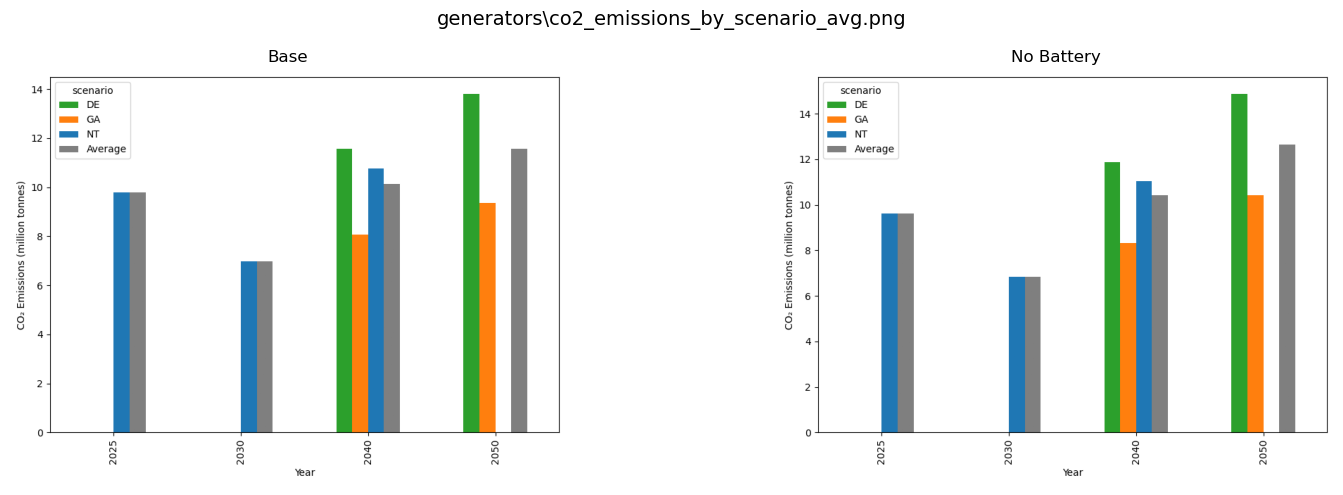

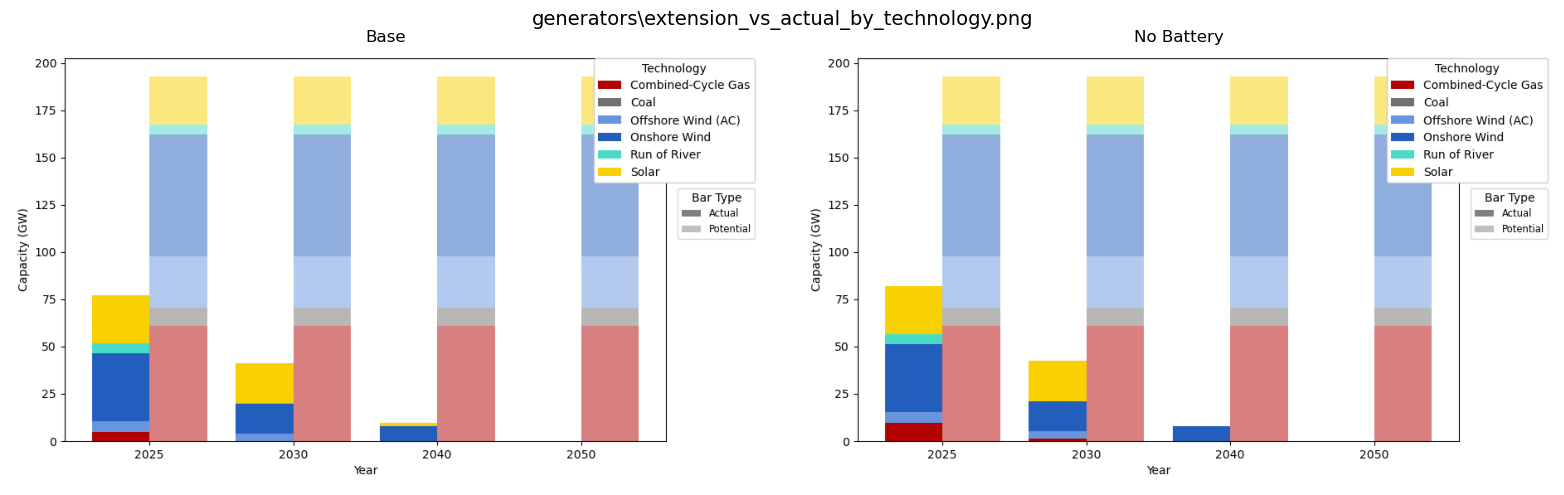

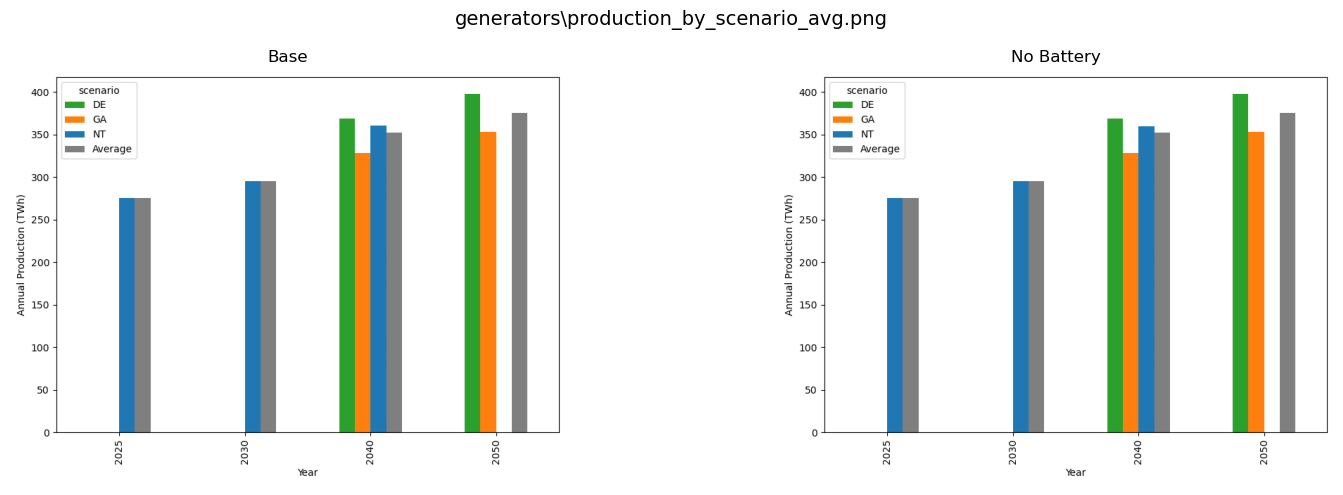

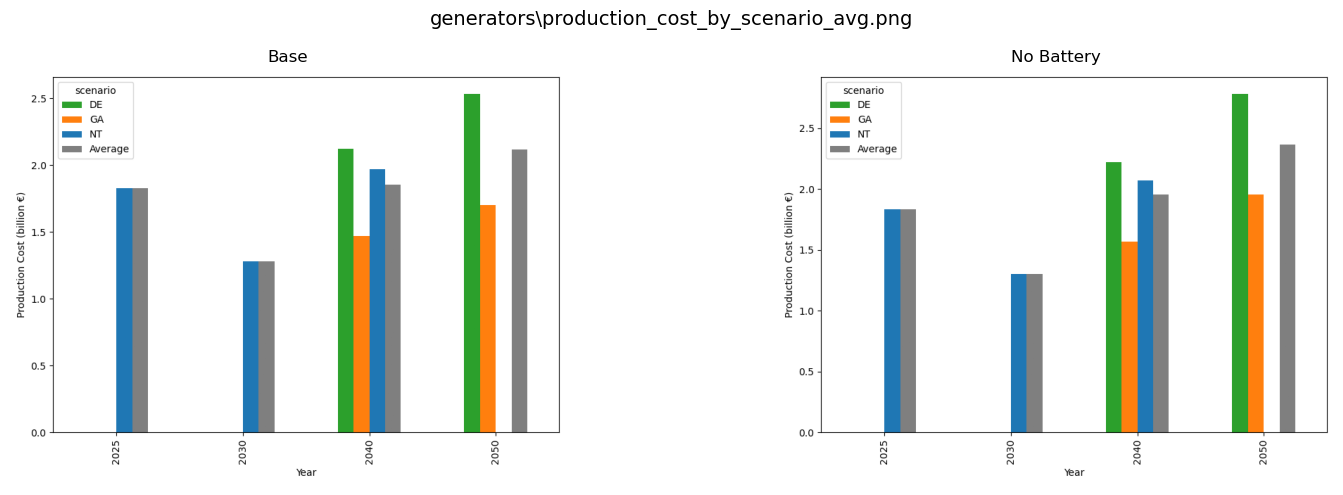

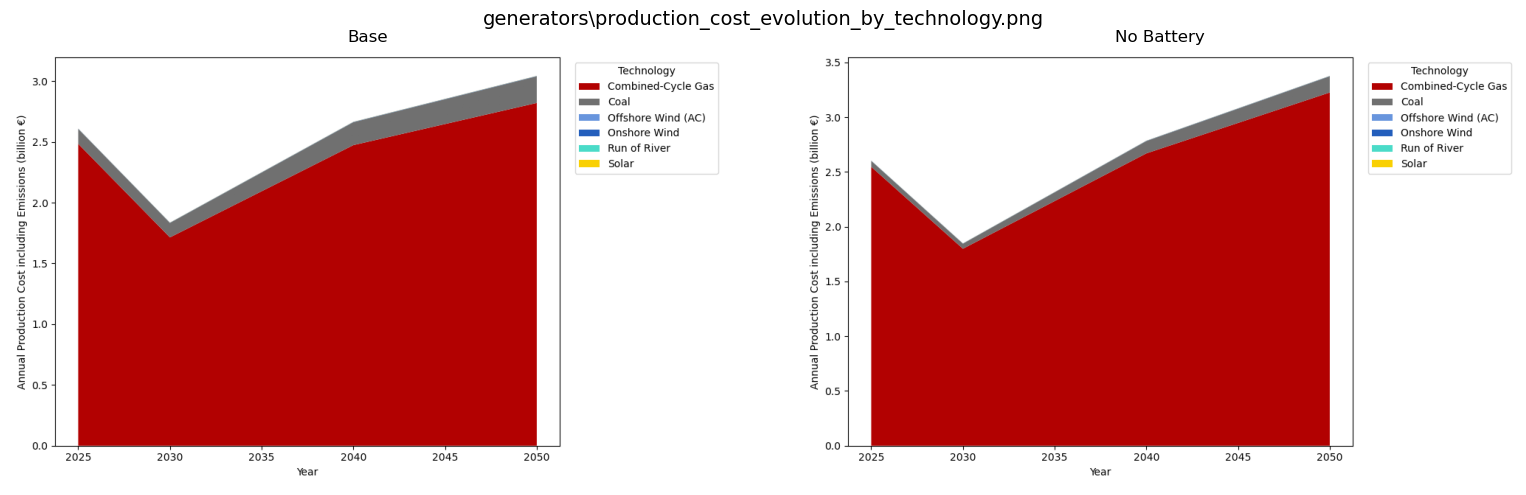

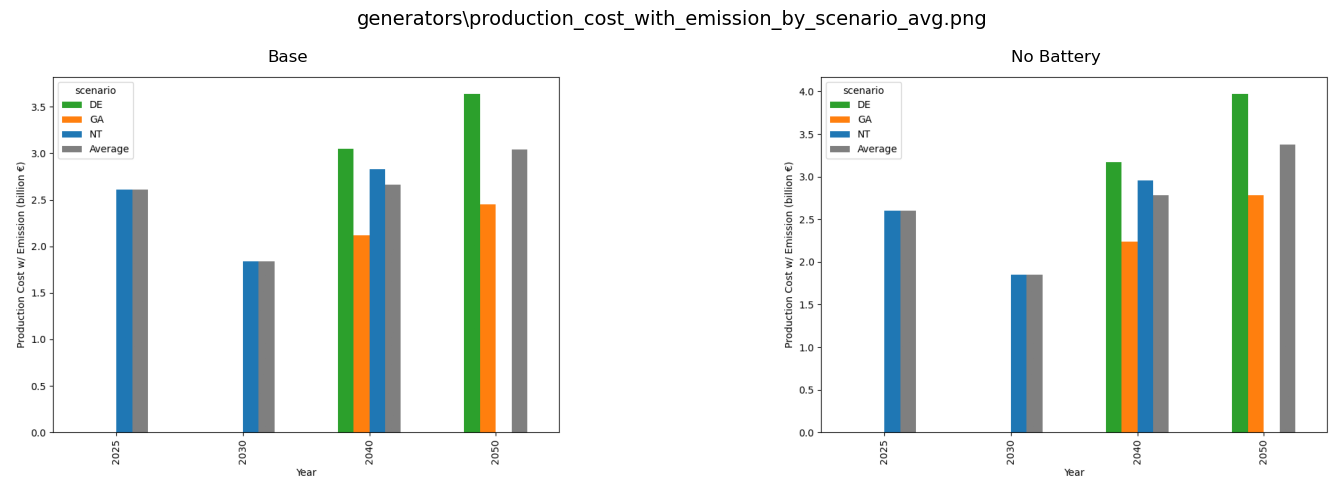

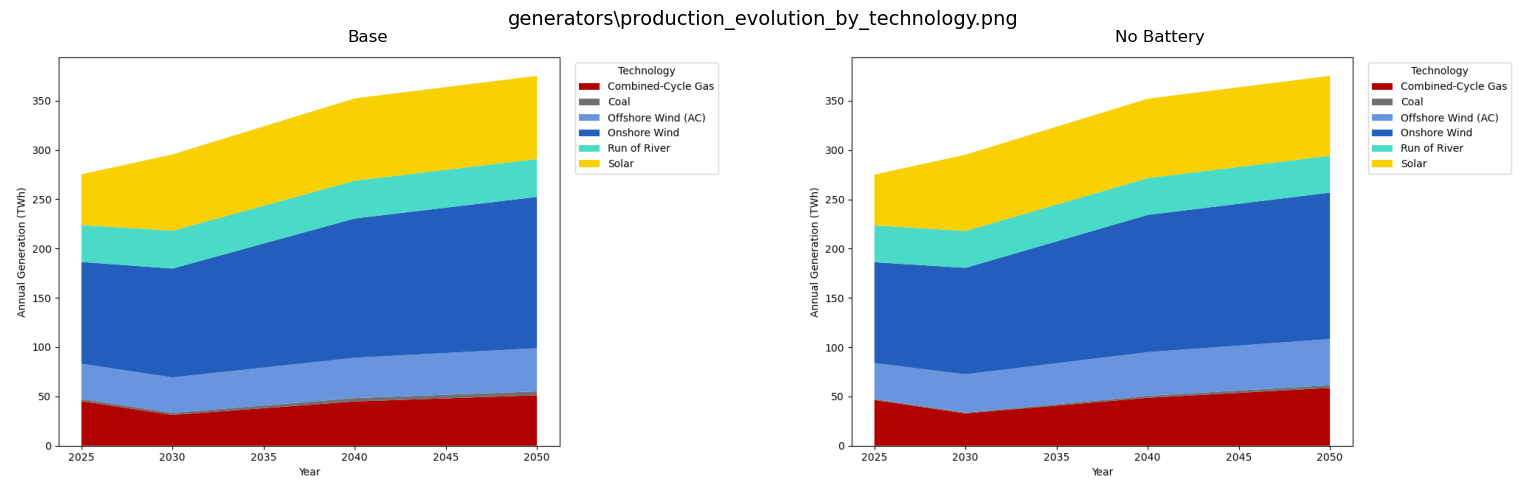

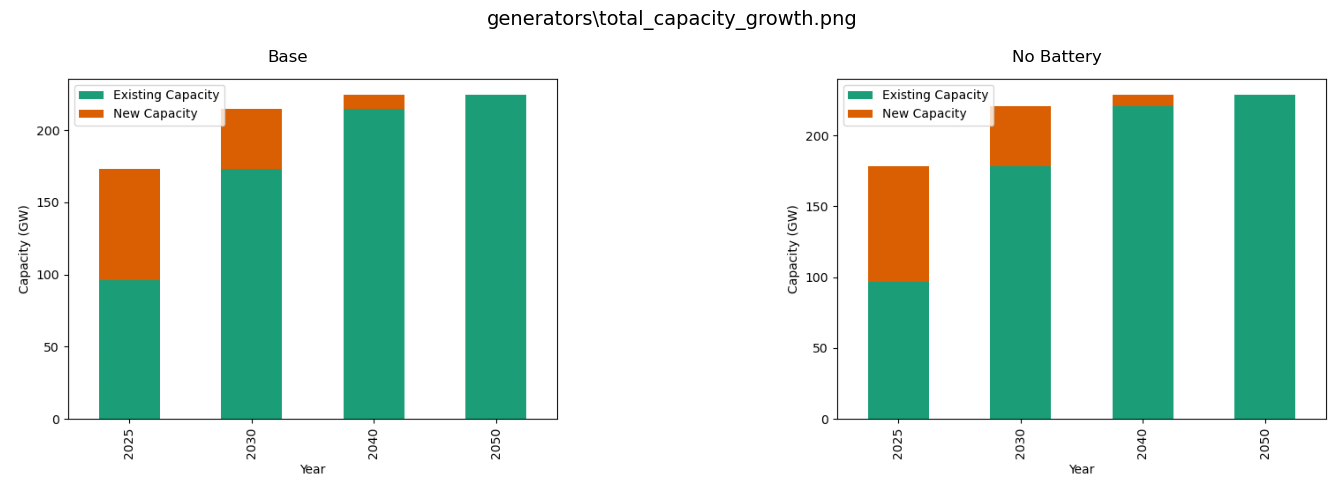

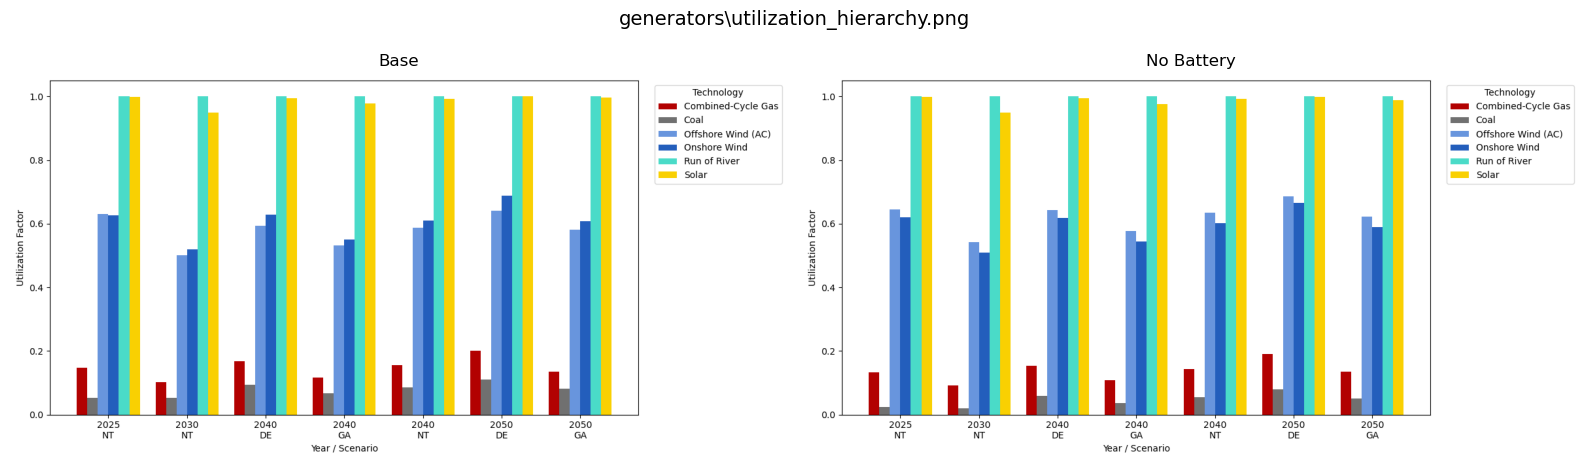


Category: macro (section: figures)


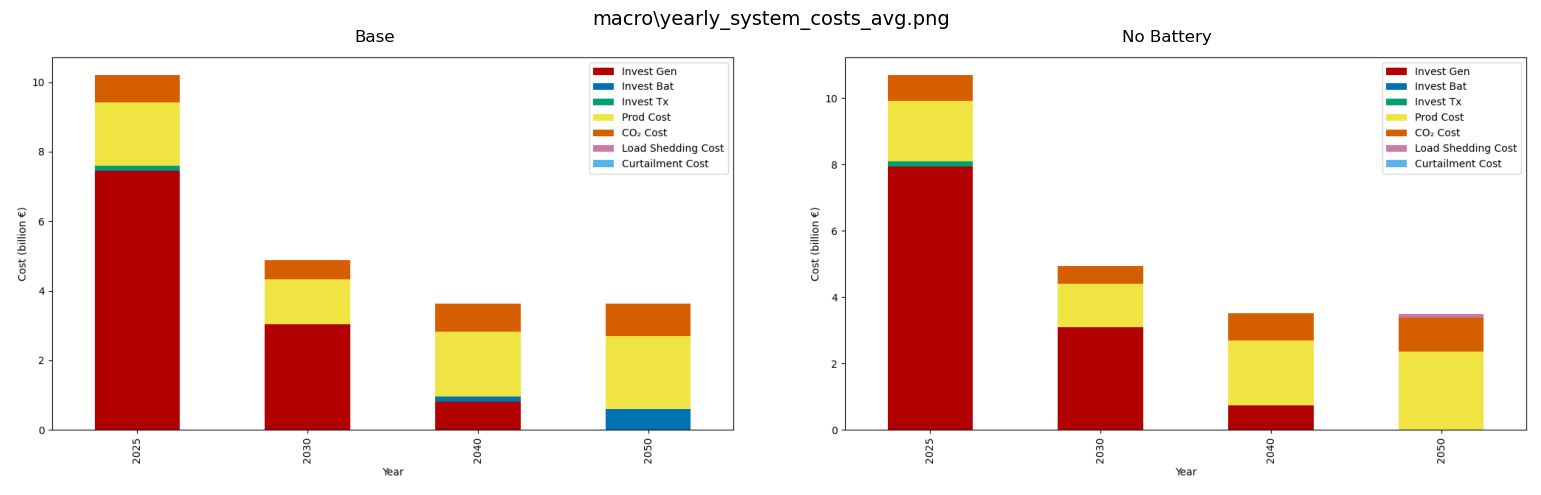

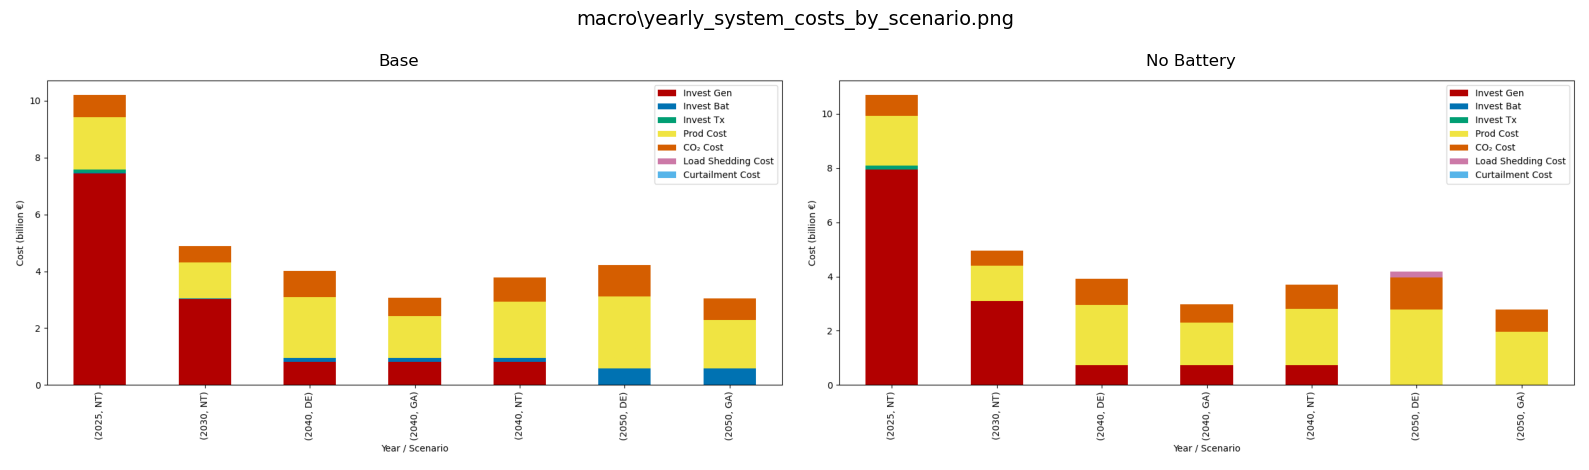

In [12]:
# To show result figures by category:
display_images_by_category(
    results_folders_to_explore, display_names, max_columns=2, section="figures"
)


Category: annual_lmp_by_scenario.png (section: duals)


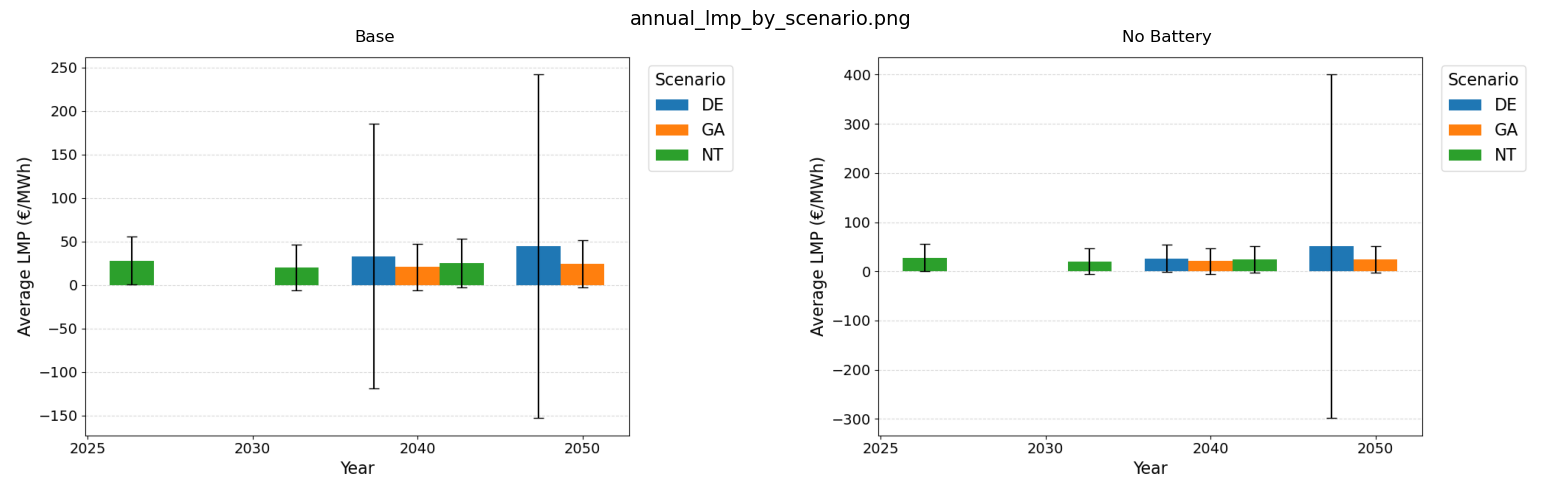


Category: annual_lmp_by_scenario_line.png (section: duals)


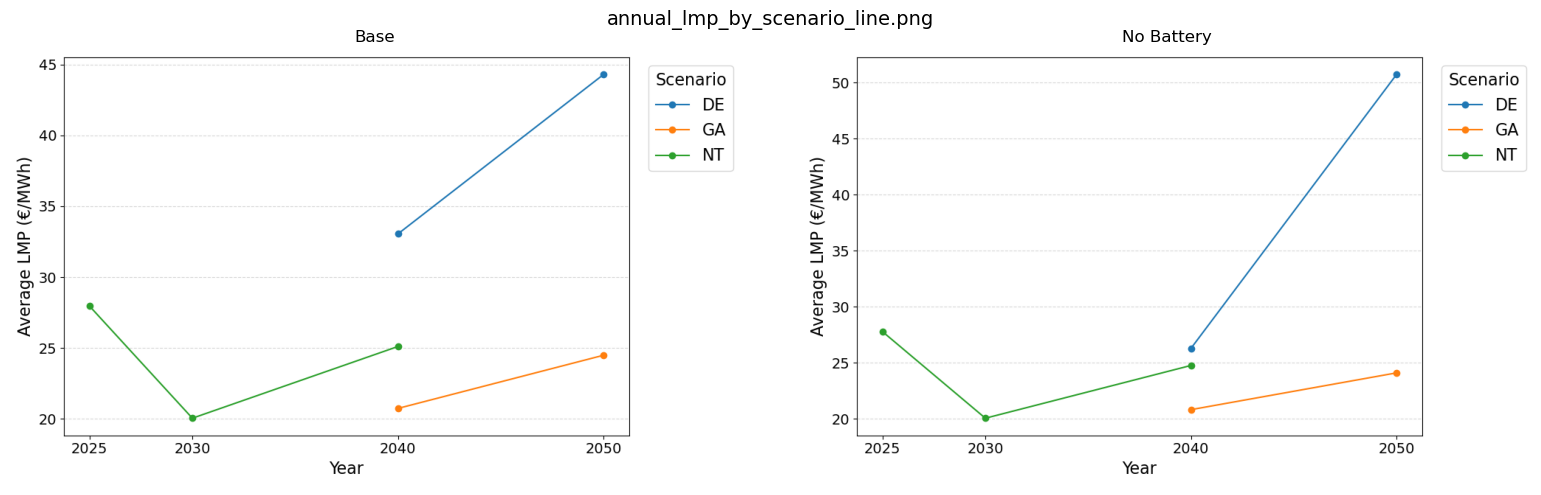


Category: annual_lmp_by_scenario_simple.png (section: duals)


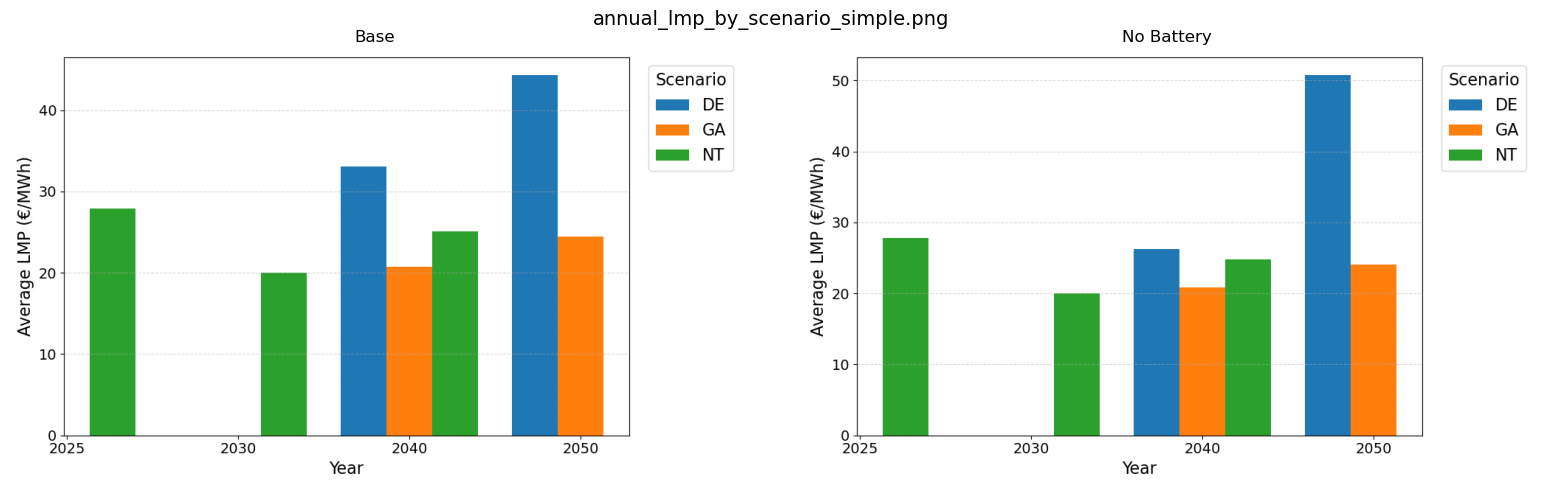


Category: gap_gap_wind_thermal_distribution.png (section: duals)


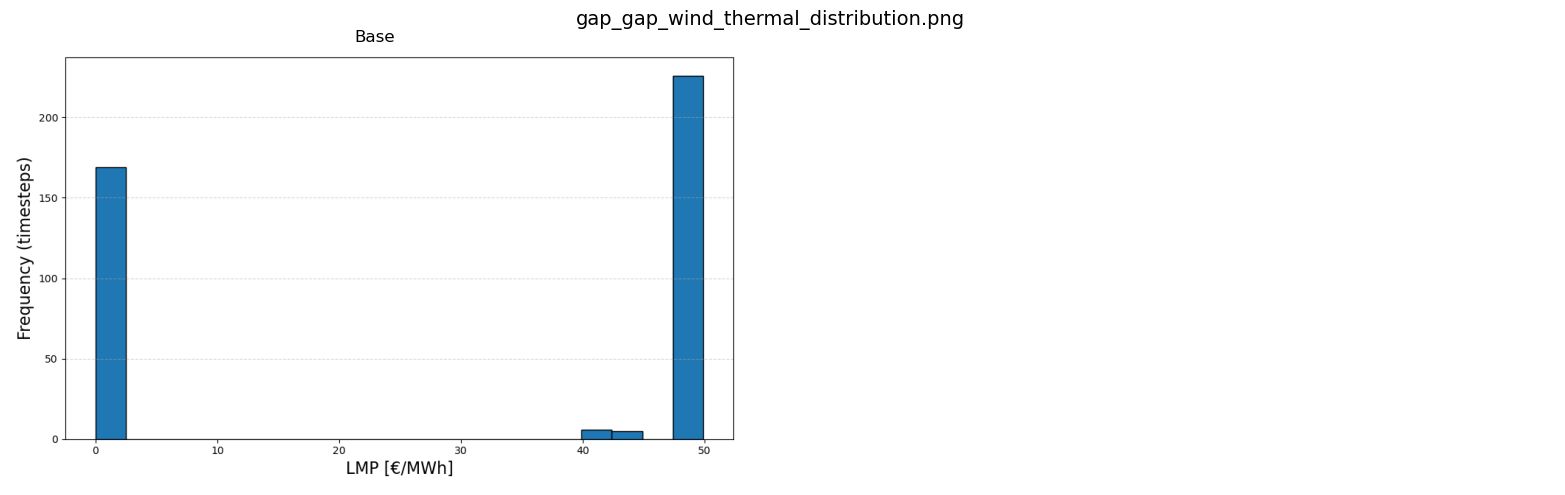


Category: high_lmp_distribution_62plus.png (section: duals)


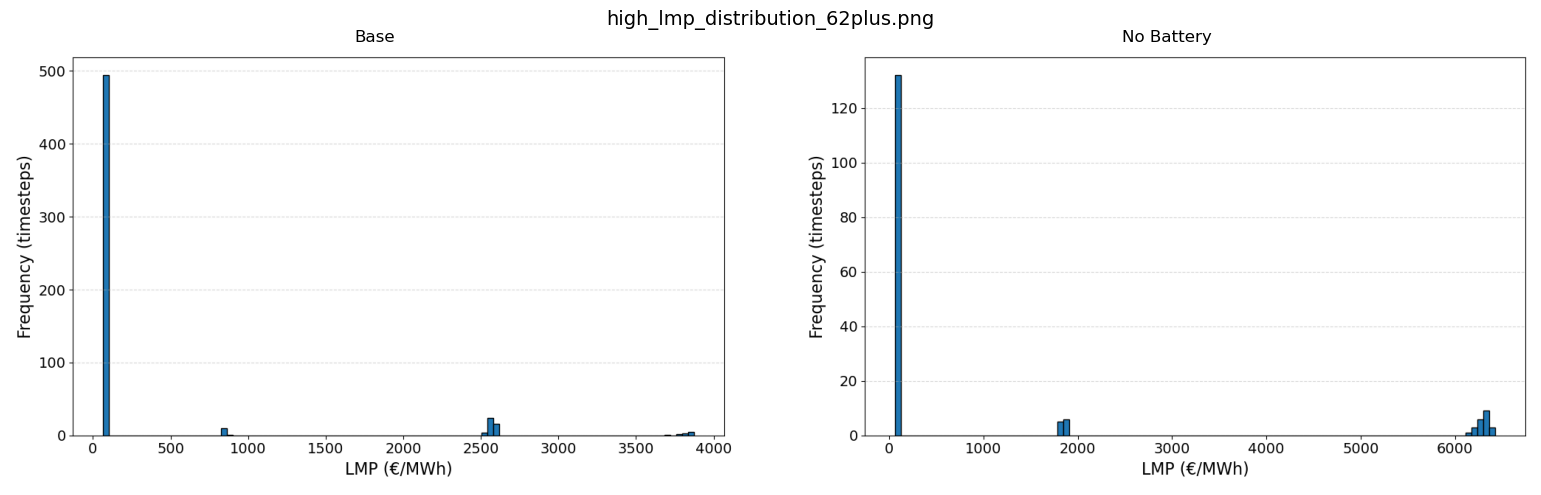


Category: high_lmp_event_counts.png (section: duals)


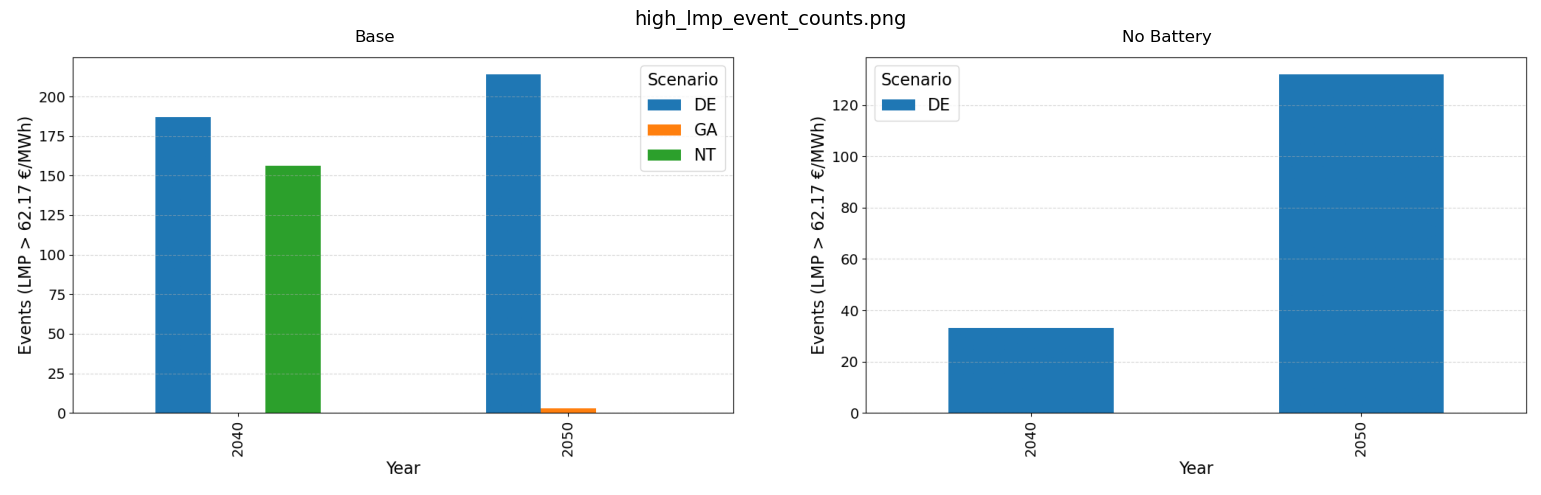


Category: lmp_buckets_2025_NT.png (section: duals)


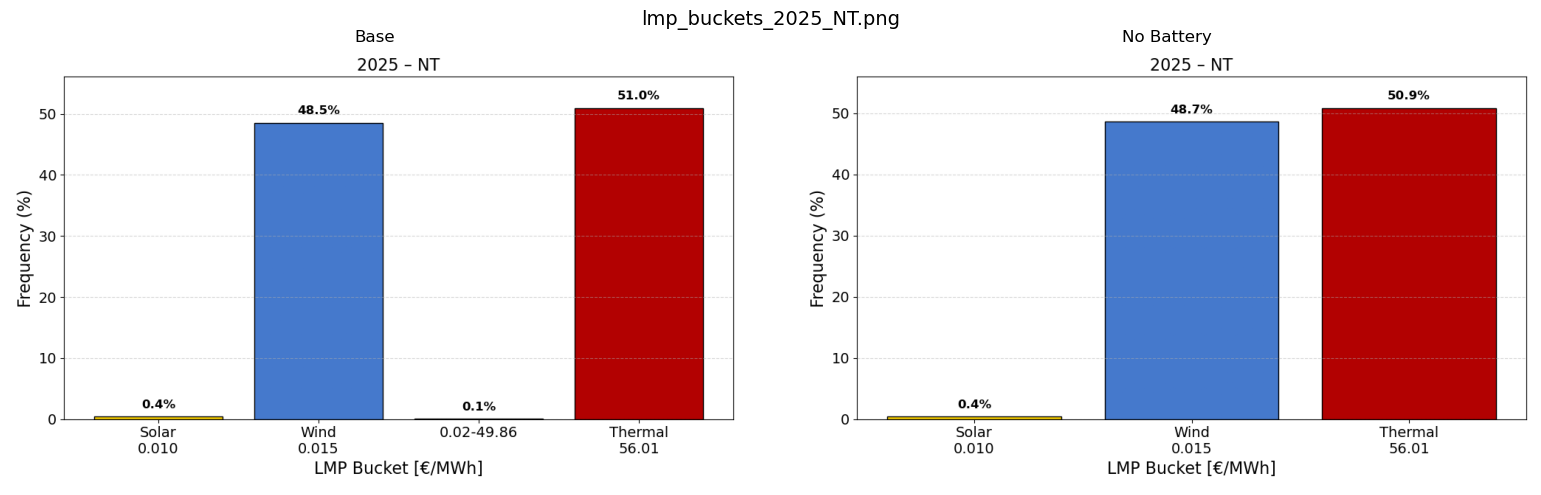


Category: lmp_buckets_2030_NT.png (section: duals)


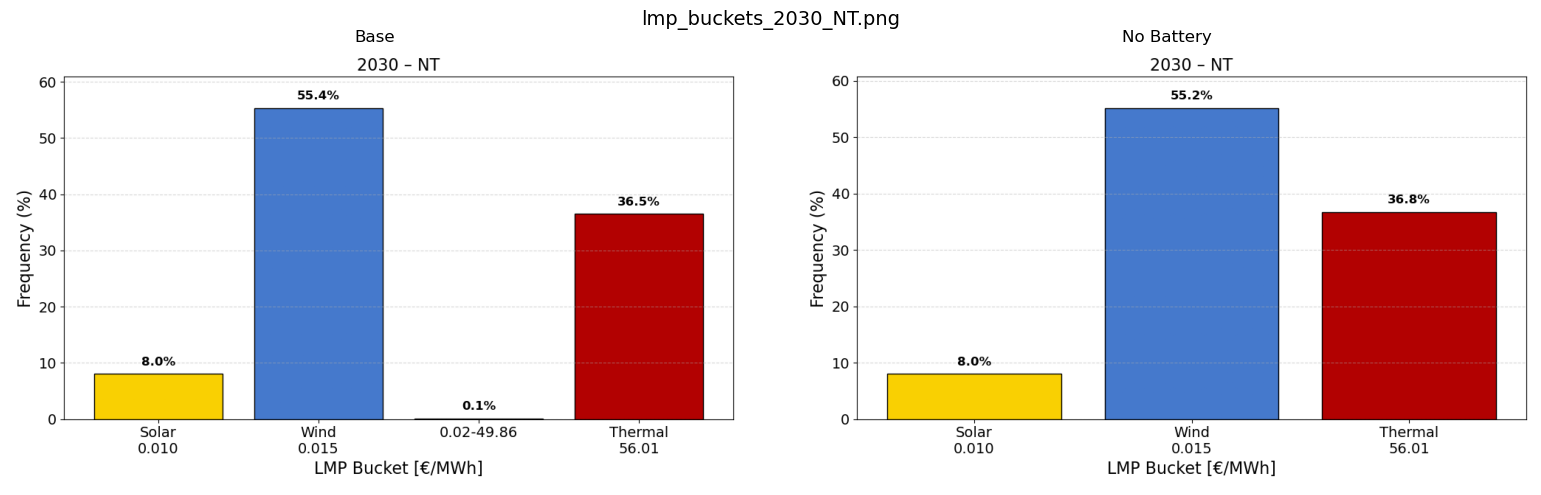


Category: lmp_buckets_2040_DE.png (section: duals)


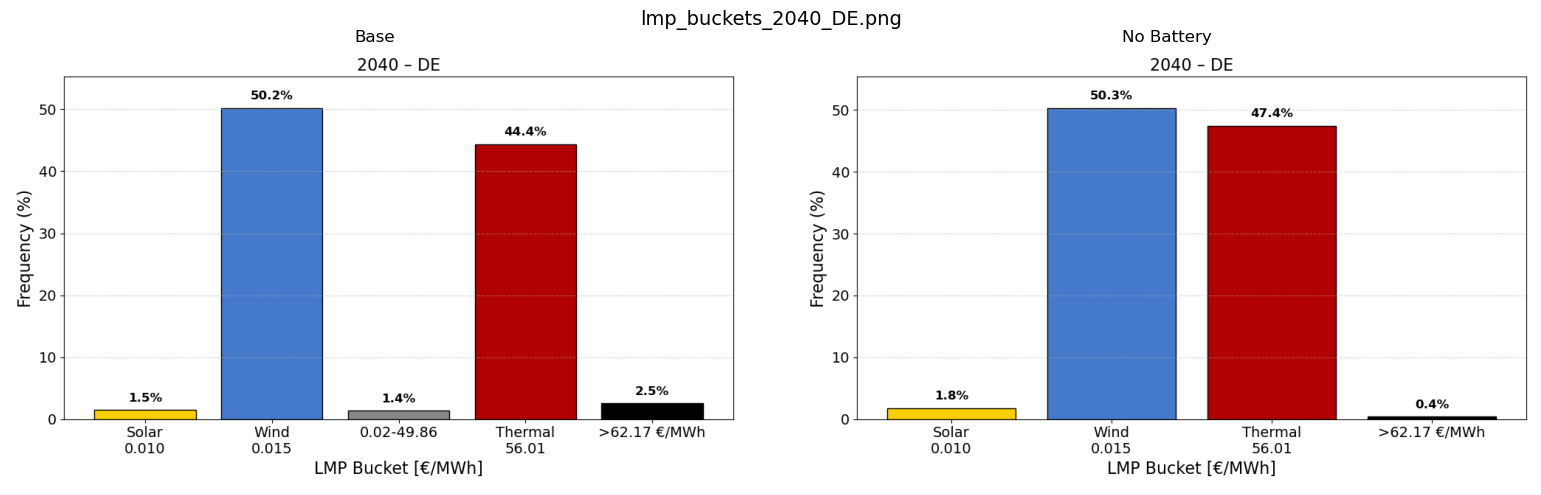


Category: lmp_buckets_2040_GA.png (section: duals)


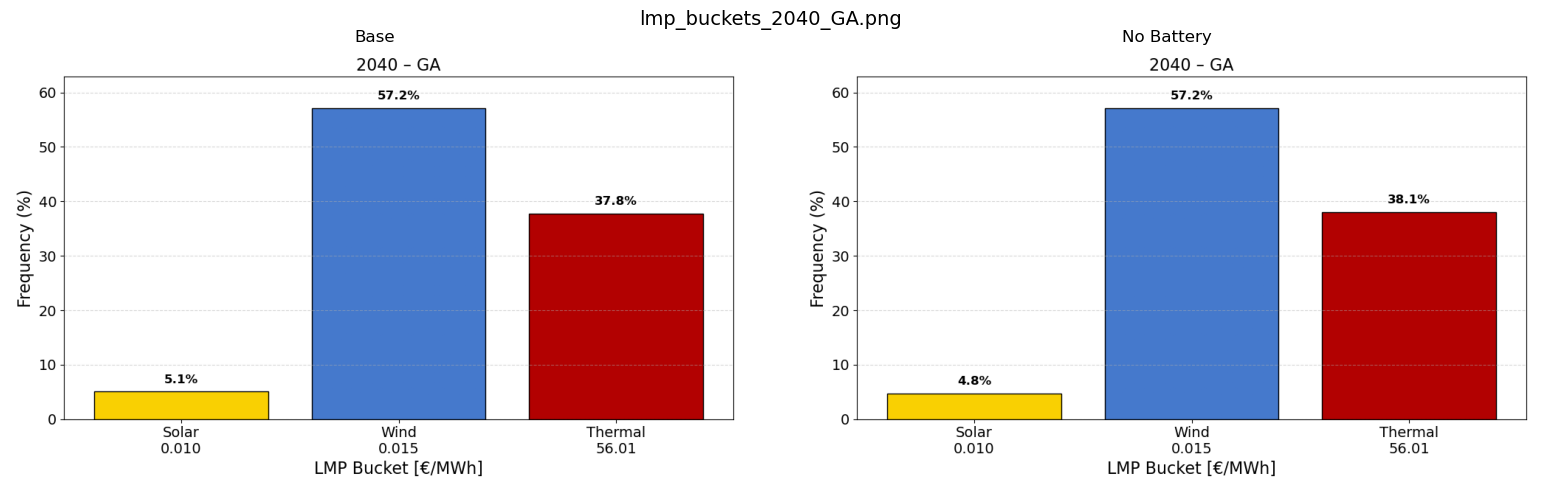


Category: lmp_buckets_2040_NT.png (section: duals)


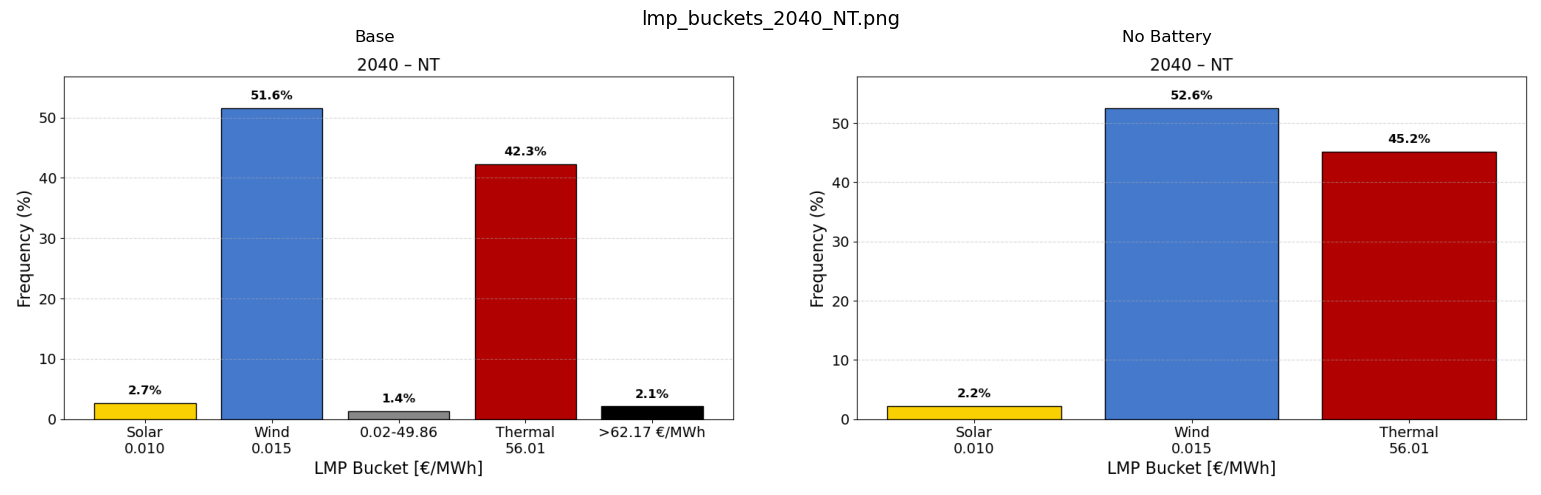


Category: lmp_buckets_2050_DE.png (section: duals)


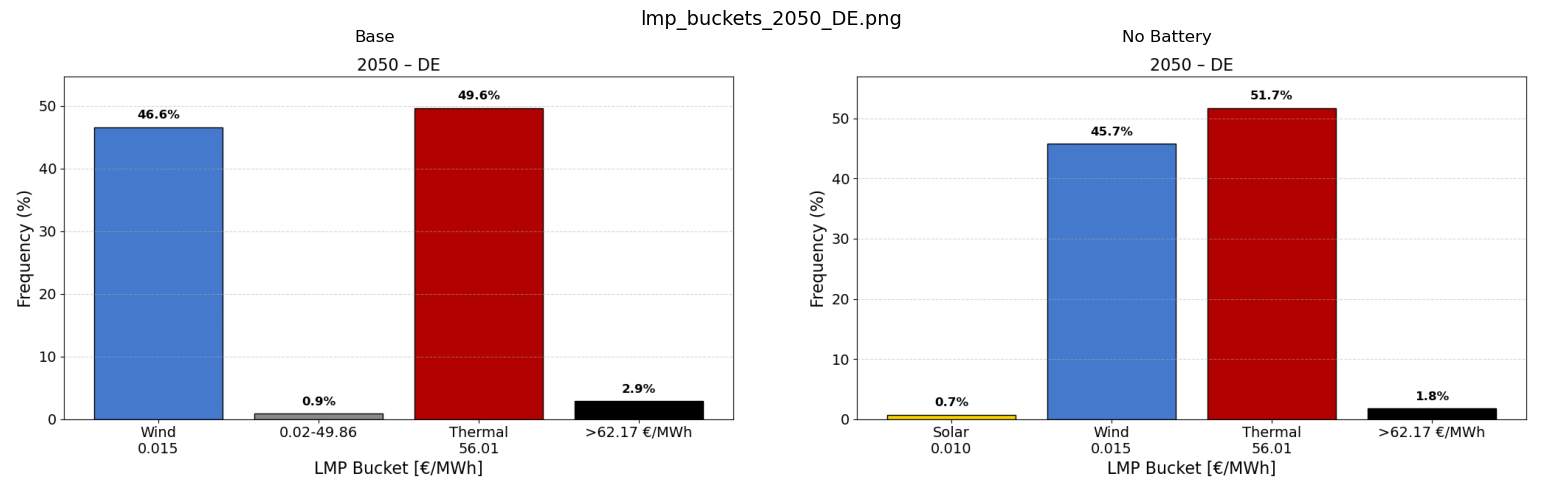


Category: lmp_buckets_2050_GA.png (section: duals)


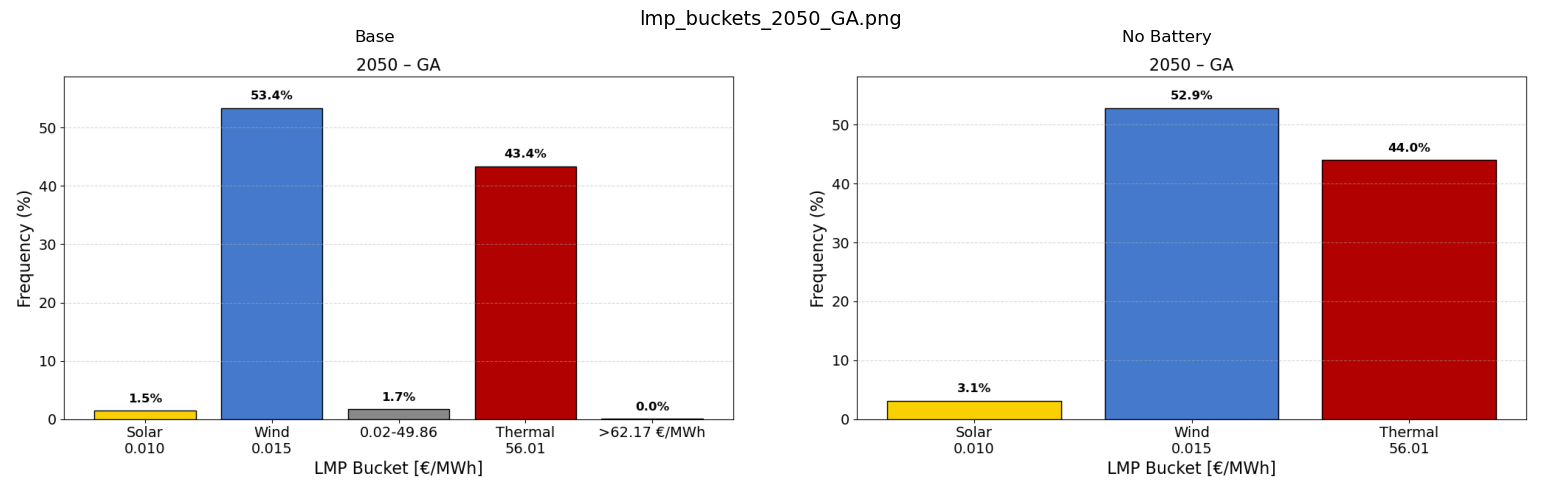


Category: lmp_bucket_frequencies.png (section: duals)


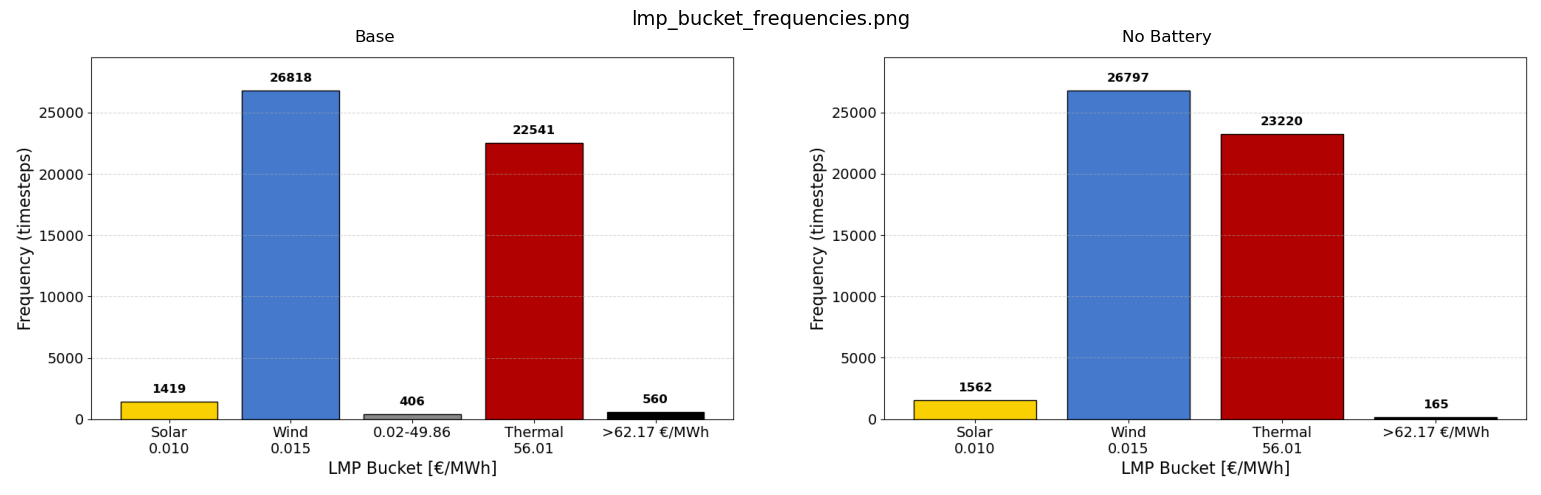


Category: lmp_bucket_percentages.png (section: duals)


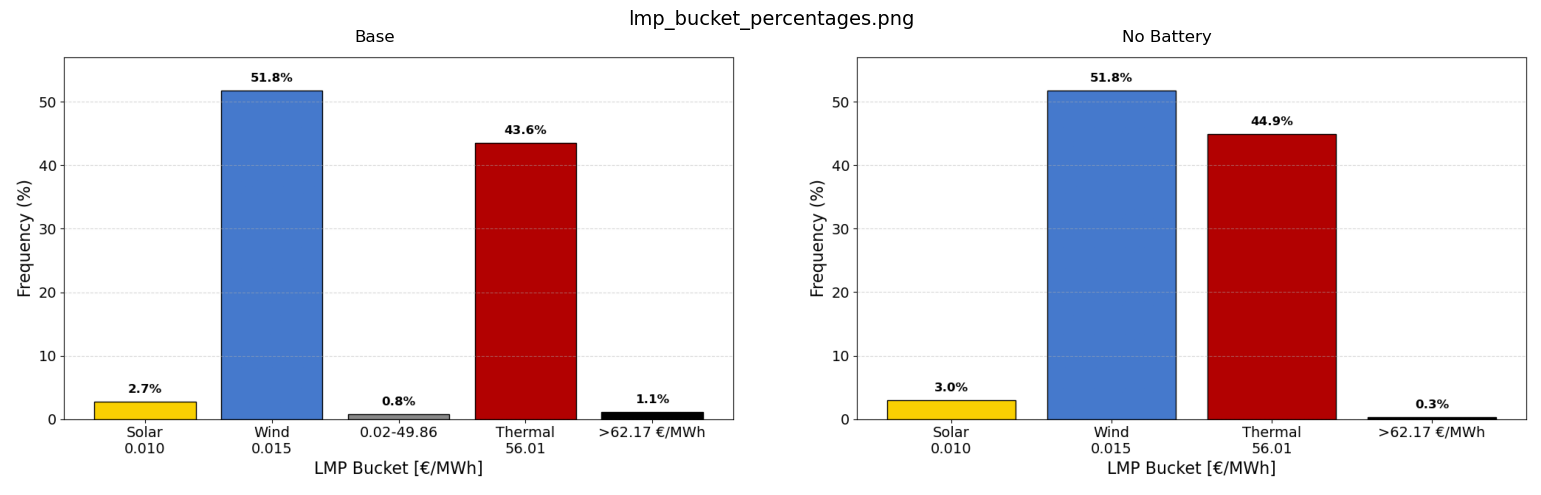


Category: lmp_histogram_70plus.png (section: duals)


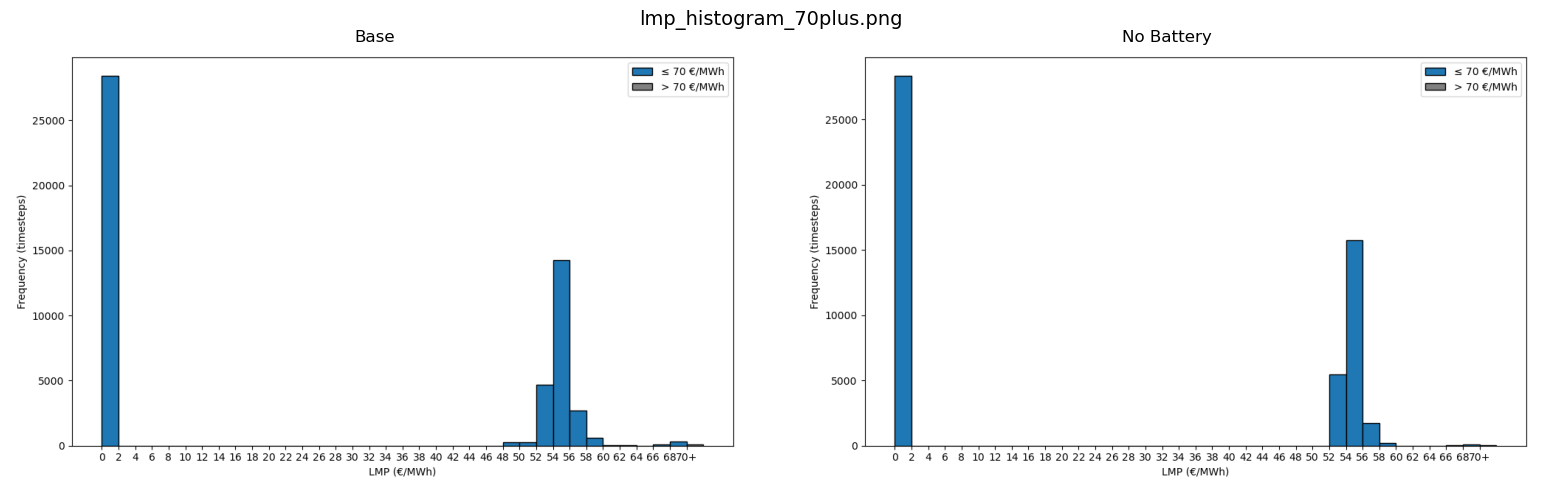


Category: nodal_price_evolution_markers.png (section: duals)


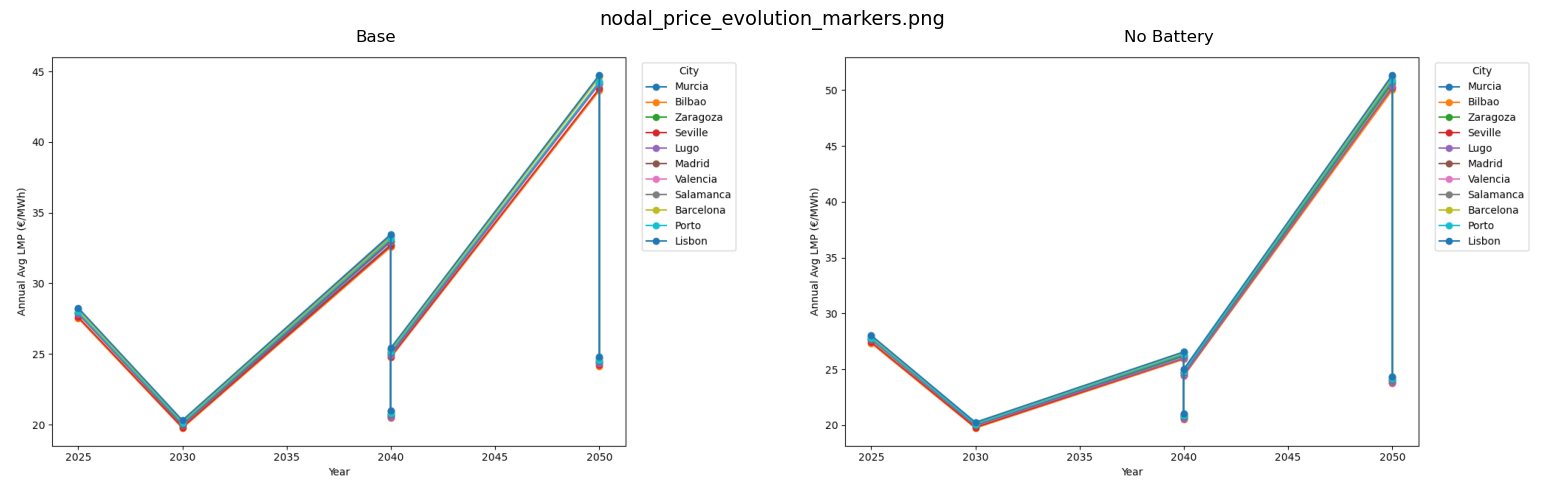


Category: nodal_price_grouped_bar.png (section: duals)


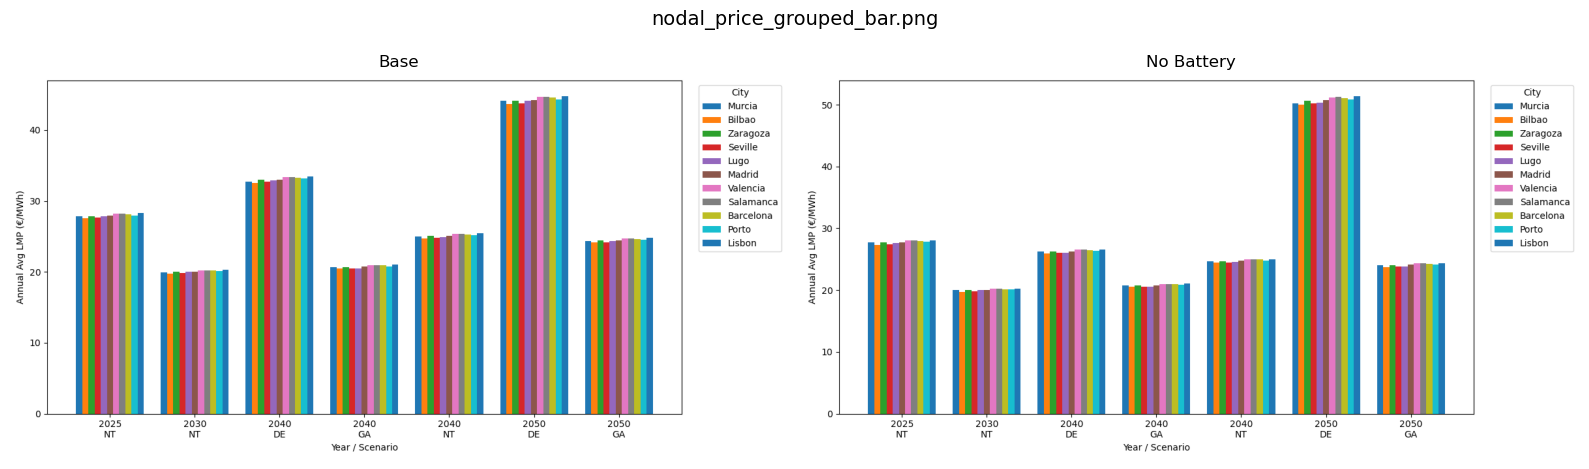


Category: top_6_high_lmp_bins.png (section: duals)


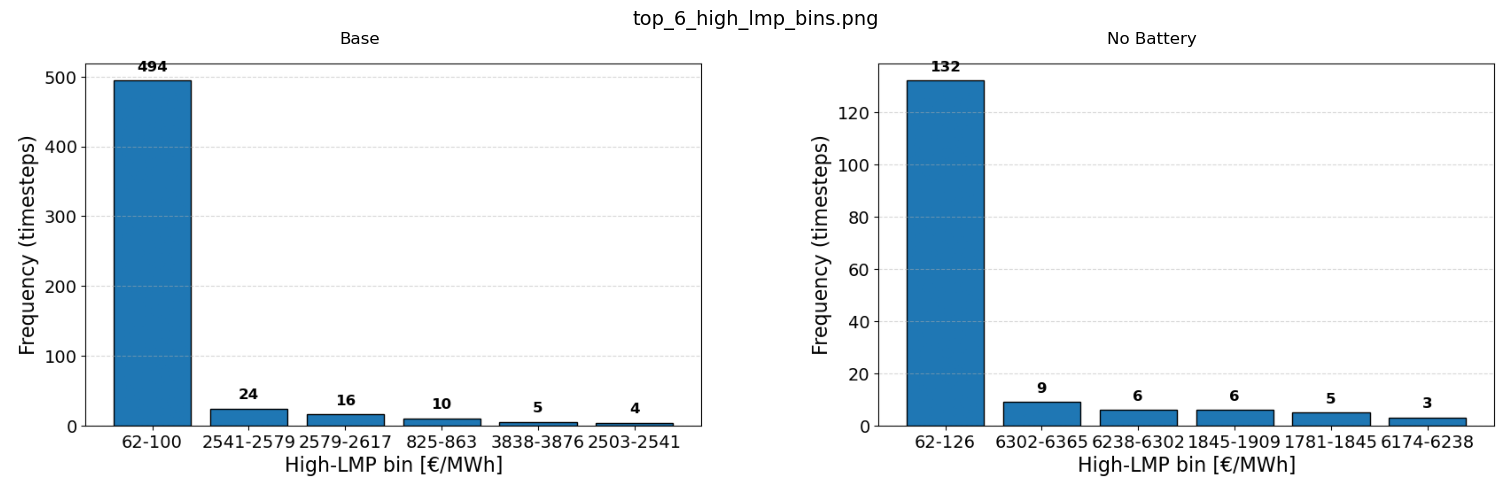


Category: top_bucket_detail_62_100_bin1.png (section: duals)


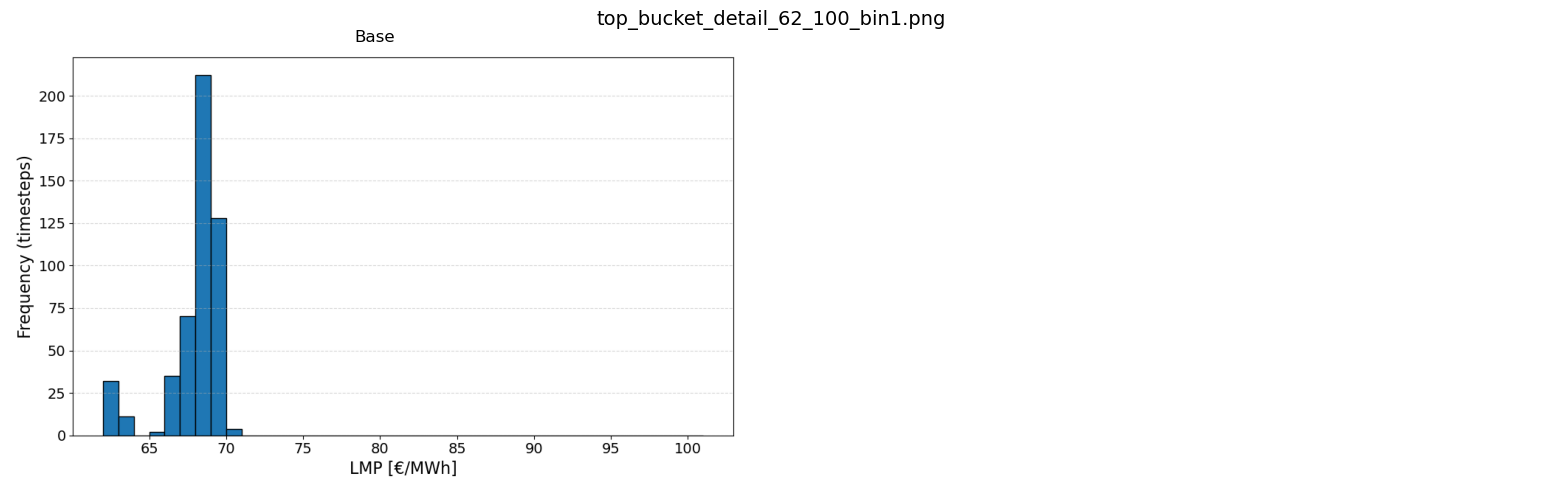


Category: dual_interval_histograms (section: duals)


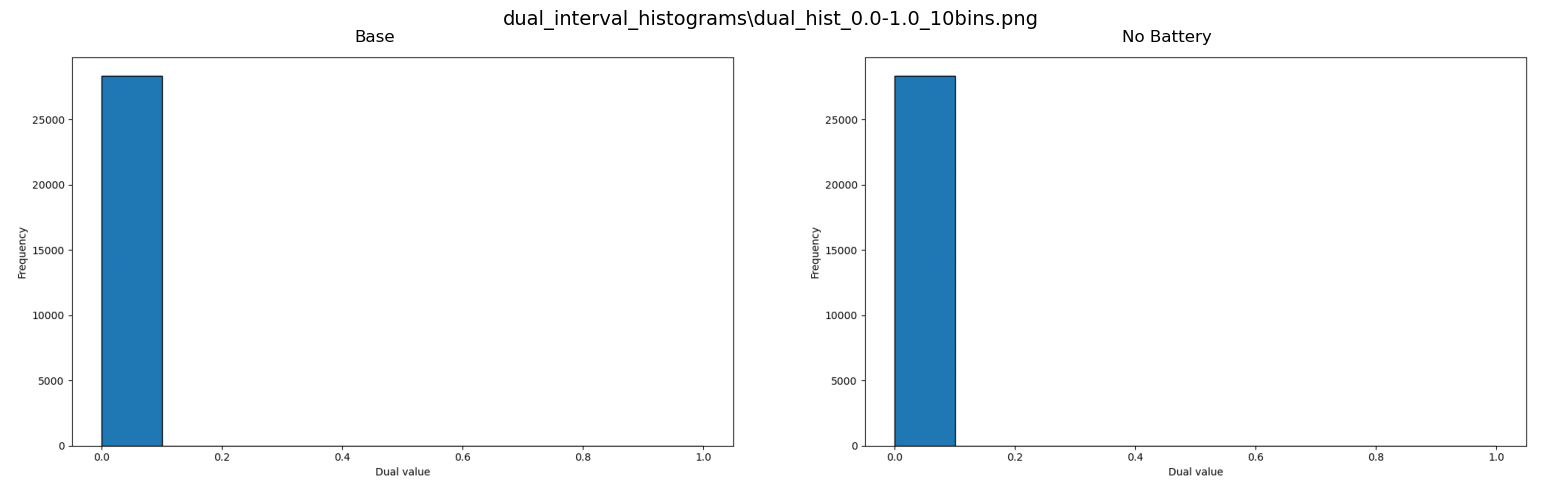

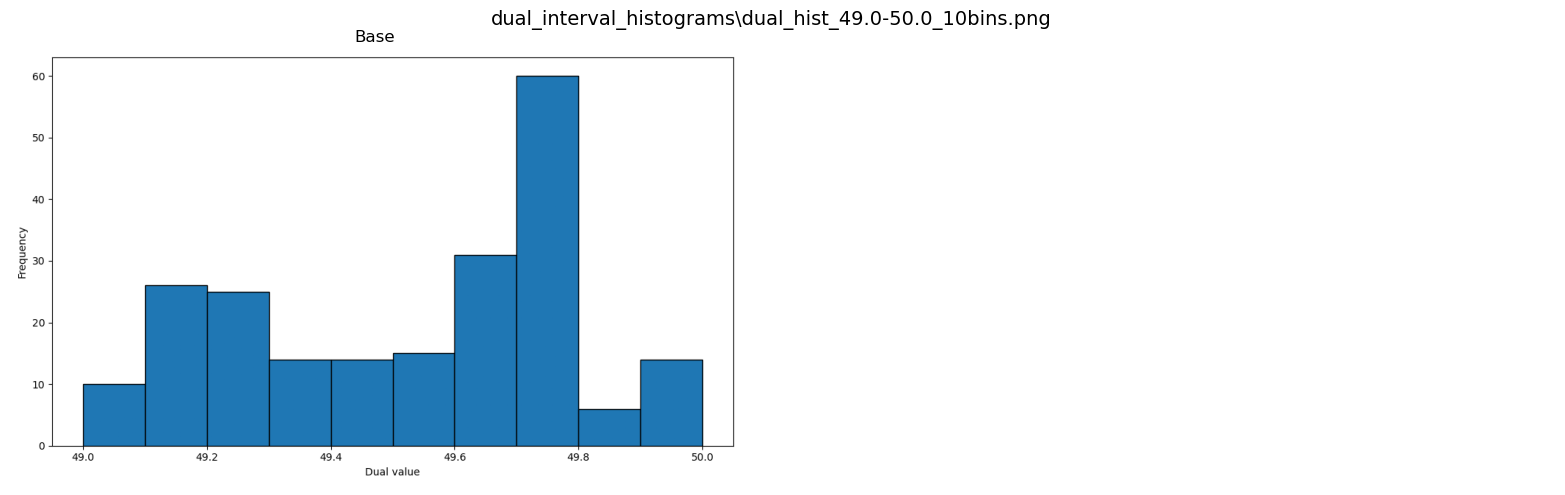

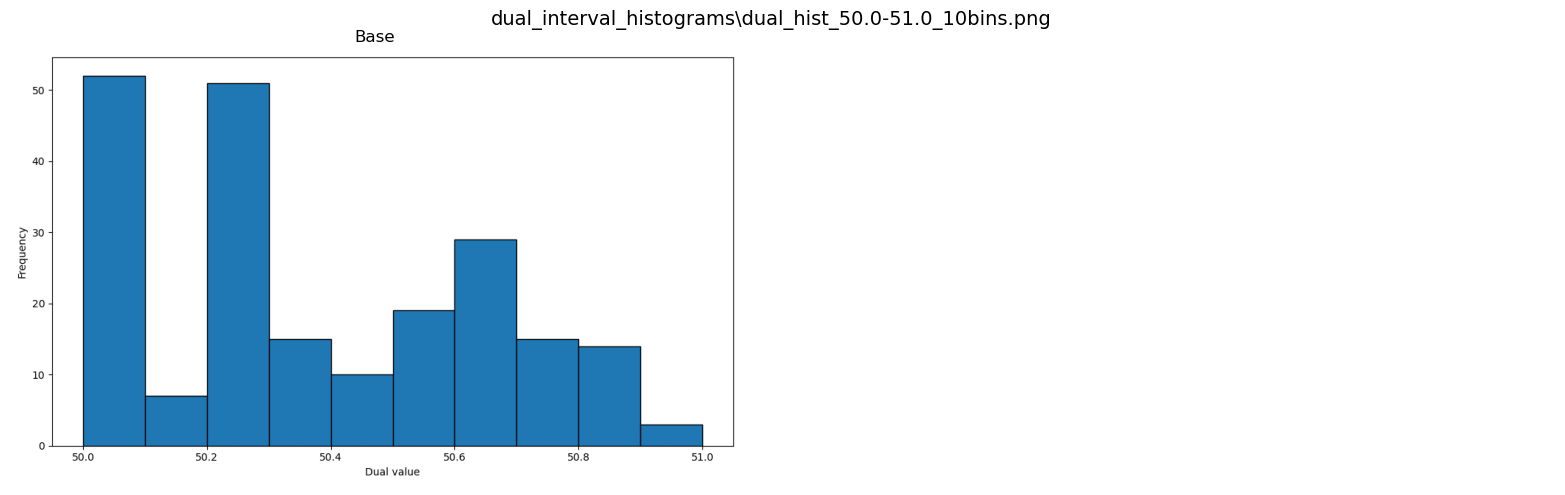

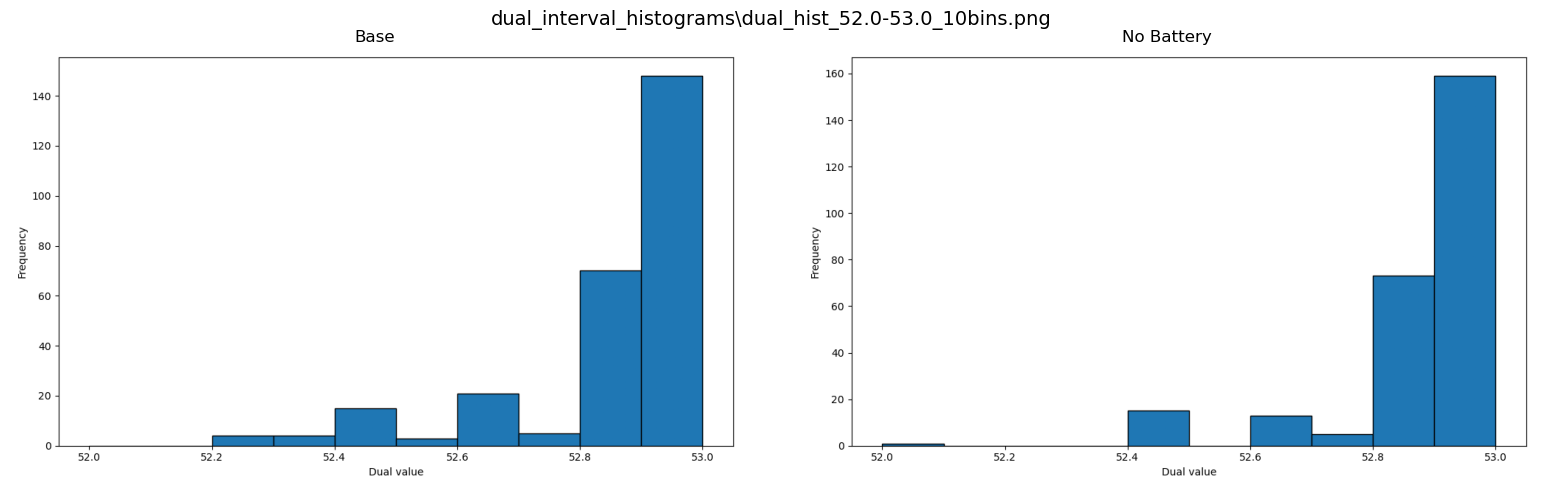

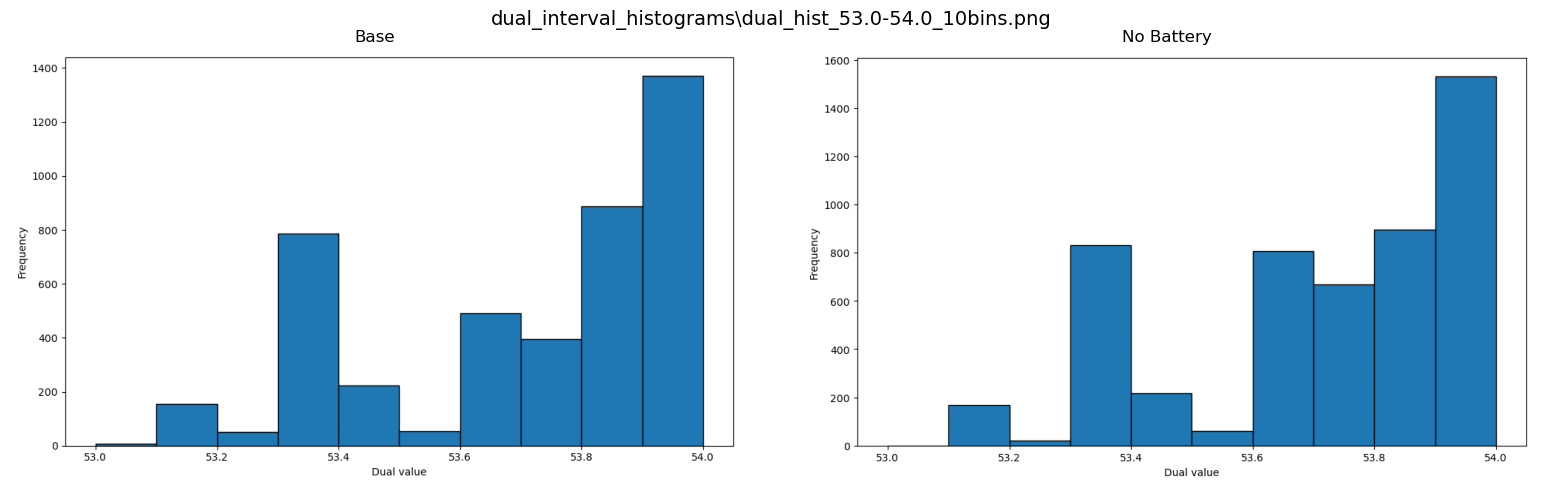

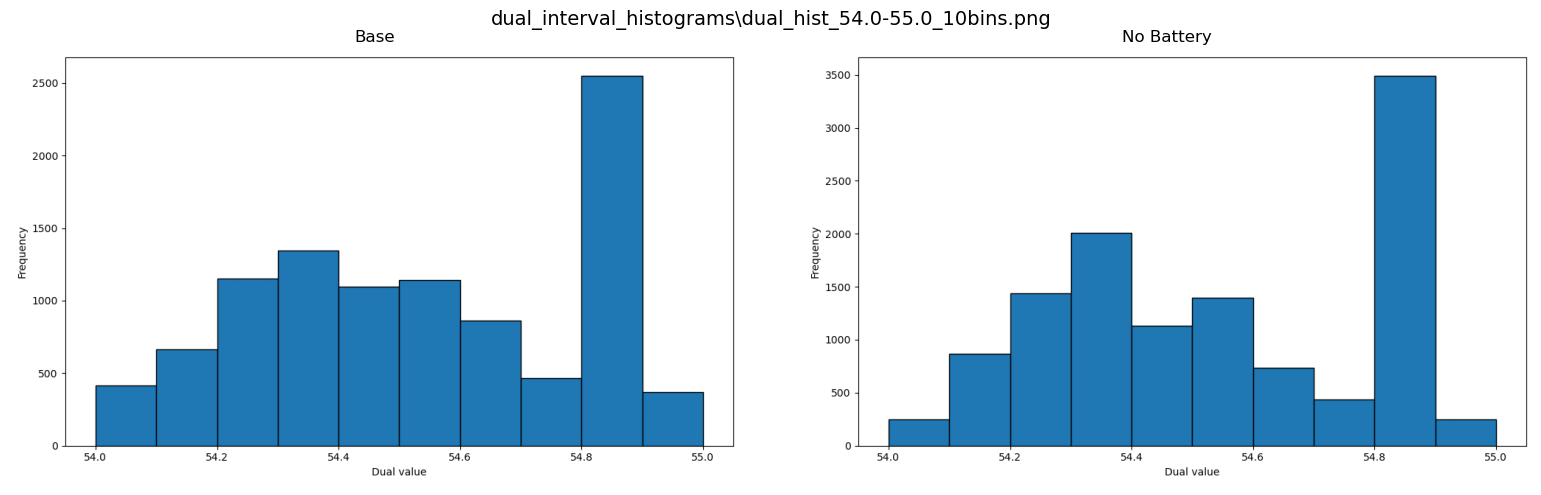

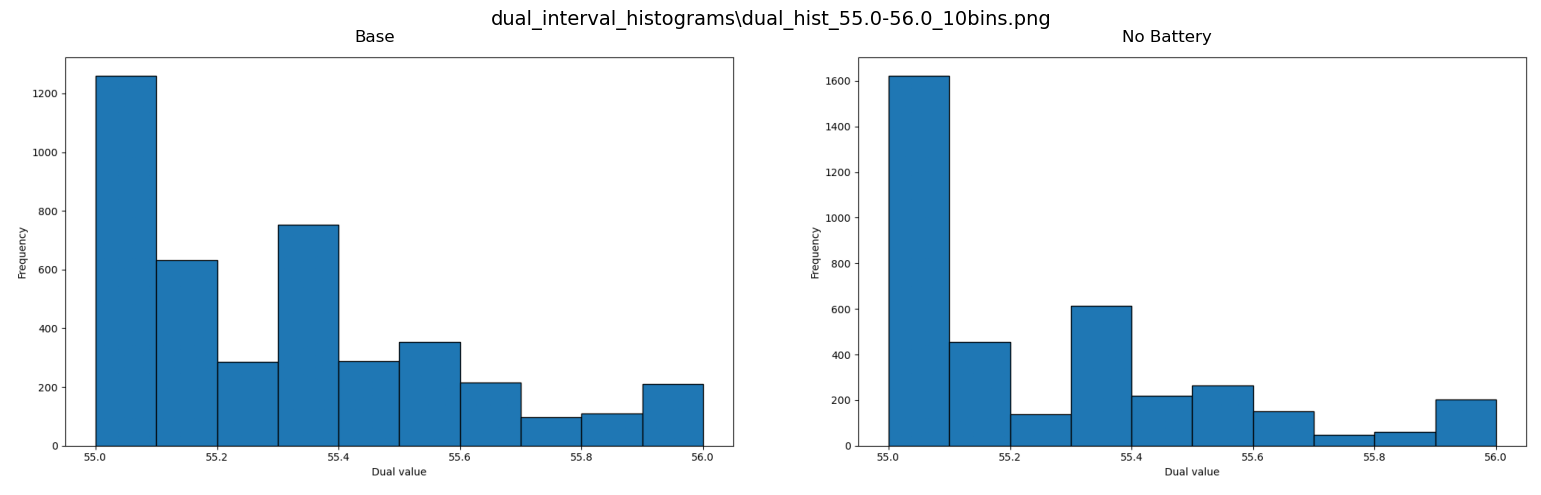

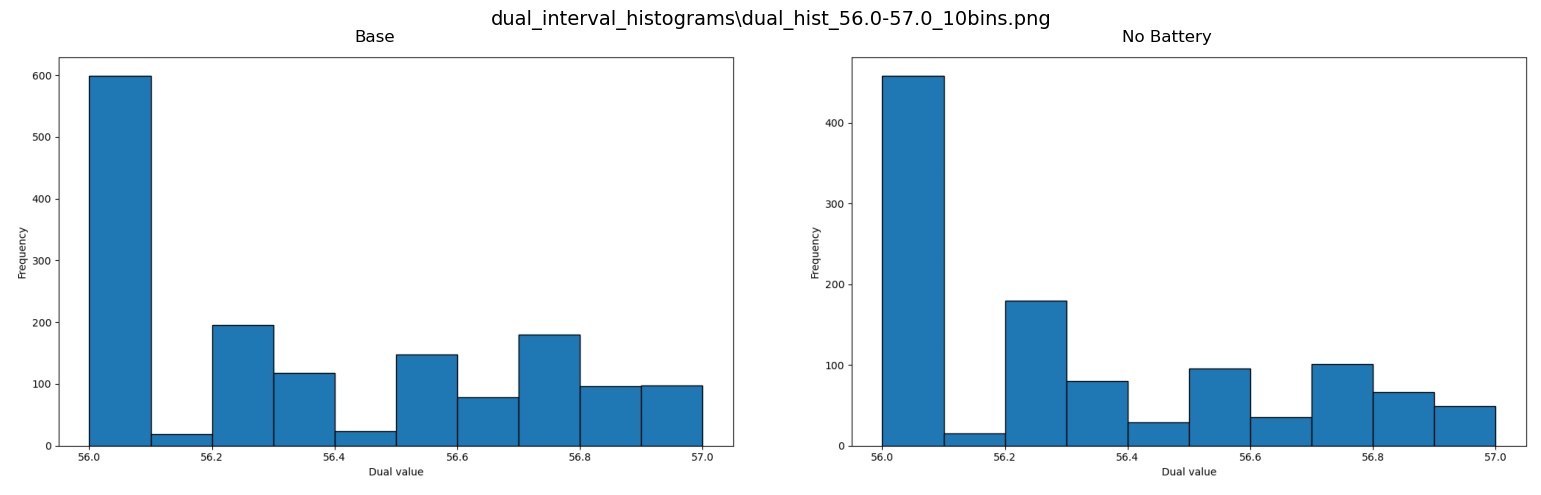

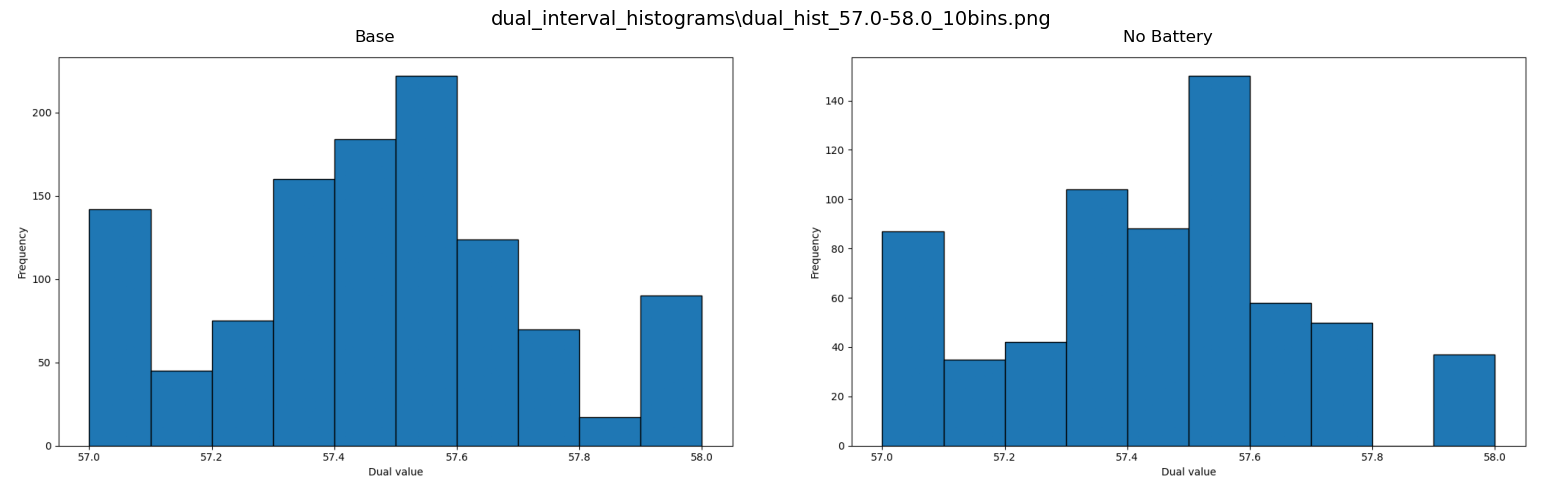

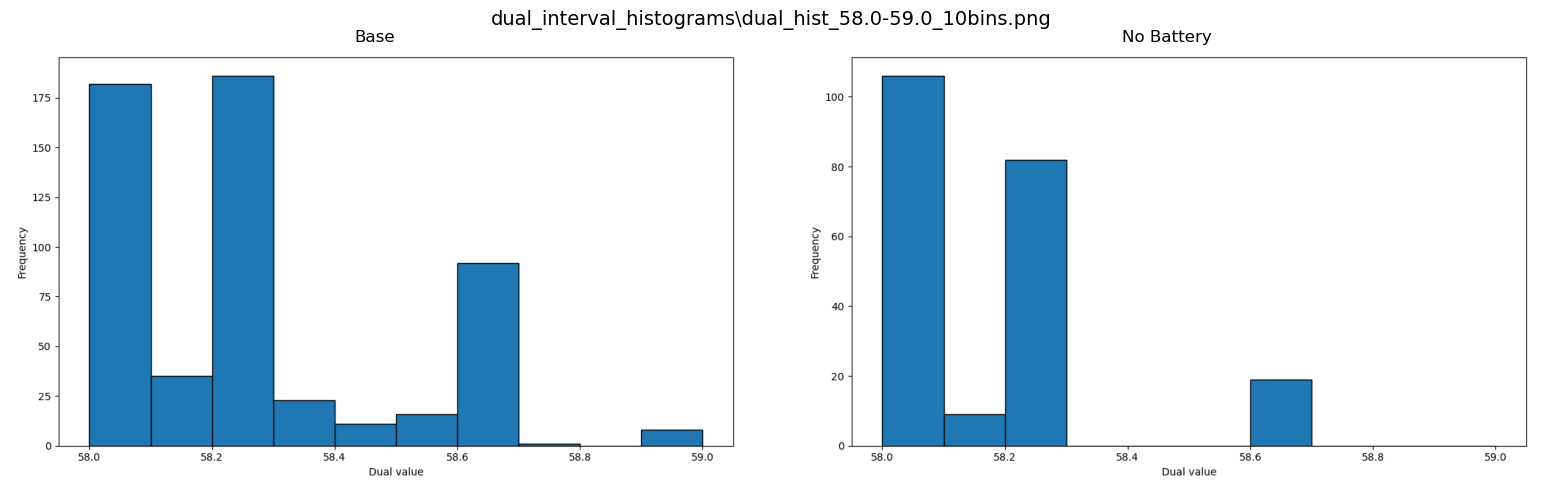

In [13]:
# To show duals images by category:
display_images_by_category(
    results_folders_to_explore, display_names, max_columns=2, section="duals"
)

In [14]:
import os
import pandas as pd


def load_and_combine_result_tables(
    results_folders: list[str],
    run_labels: list[str],
    tables_subdir: str = "results/tables",
) -> dict[str, pd.DataFrame]:
    """
    Discover all CSVs under each run's results/tables folder, then load and
    combine them across runs for easy comparison.

    If any table has a non-unique index when read with index_col=0, it is
    instead read without an index to avoid alignment errors.

    Returns a dict mapping each relative CSV path to a combined DataFrame with
    a MultiIndex on columns: (run_label, original_column).
    """
    # 1) Gather all relative CSV paths
    all_rel_paths = set()
    for folder in results_folders:
        base = os.path.join(folder, tables_subdir)
        for root, _, files in os.walk(base):
            for file in files:
                if file.lower().endswith(".csv"):
                    full_path = os.path.join(root, file)
                    rel = os.path.relpath(full_path, base)
                    all_rel_paths.add(rel)

    combined_tables = {}
    for rel in sorted(all_rel_paths):
        # collect per-run DataFrames
        run_dfs = {}
        for folder, label in zip(results_folders, run_labels):
            path = os.path.join(folder, tables_subdir, rel)
            if not os.path.exists(path):
                continue
            # try reading with index_col=0
            df = pd.read_csv(path, index_col=0)
            # if the index is not unique, re-read without index
            if not df.index.is_unique:
                df = pd.read_csv(path, index_col=None)
            run_dfs[label] = df

        if not run_dfs:
            continue

        # 2) Concatenate side-by-side with run_labels as first-level column keys
        combined = pd.concat(run_dfs, axis=1)
        combined_tables[rel] = combined

    return combined_tables

In [15]:
combined = load_and_combine_result_tables(results_folders_to_explore, display_names)

combined.keys()

dict_keys(['batteries\\battery_system_summary_by_year.csv', 'battery_system_summary_by_year.csv', 'branches\\aggregate_branch_flow_summary.csv', 'branches\\branch_buildout_summary_by_year.csv', 'branches\\branch_flow_metrics.csv', 'curtailment_load_shedding_costs.csv', 'duals\\annual_lmp_overall_average.csv', 'duals\\annual_lmp_table.csv', 'duals\\dual_nonzero_summary.csv', 'duals\\dual_year_scenario_summary.csv', 'duals\\gap_wind_thermal_dual_summary.csv', 'duals\\gen_extension_nonzero_duals.csv', 'duals\\high_lmp_freq_table_62plus.csv', 'duals\\lmp_bucket_frequencies.csv', 'duals\\lmp_frequency_table.csv', 'duals\\lmp_frequency_table_sorted.csv', 'duals\\nodal_price_table.csv', 'duals\\top_10_high_lmp_bins.csv', 'extended_tables\\extended_batteries.csv', 'extended_tables\\extended_branches.csv', 'extended_tables\\extended_generators.csv', 'generators\\annual_production_by_carrier_and_scenario.csv', 'generators\\annual_weighted_cost_by_carrier.csv', 'generators\\annual_weighted_produc

In [16]:
def load_and_combine_result_tables_by_category(
    results_folders: list[str],
    run_labels: list[str],
    tables_subdir: str = "results/tables",
) -> dict[str, dict[str, pd.DataFrame]]:
    """
    Discover all CSVs under each run's results/tables folder, then load and
    combine them across runs, organizing them by top-level category.

    Now concatenates along rows, using run_labels as the outer index level
    ('scenario'), so that the first index is the scenario name and the second
    is the original table index. Table names drop the '.csv'.
    """
    # 1) Gather all relative CSV paths
    all_rel_paths = set()
    for folder in results_folders:
        base = os.path.join(folder, tables_subdir)
        for root, _, files in os.walk(base):
            for file in files:
                if file.lower().endswith(".csv"):
                    rel = os.path.relpath(os.path.join(root, file), base)
                    all_rel_paths.add(rel)

    nested: dict[str, dict[str, pd.DataFrame]] = {}
    # 2) For each CSV, load each run's table, then concat down rows
    for rel in sorted(all_rel_paths):
        per_run_dfs = []
        for folder, label in zip(results_folders, run_labels):
            path = os.path.join(folder, tables_subdir, rel)
            if not os.path.exists(path):
                continue
            # read CSV, first col as index if possible
            df = pd.read_csv(path, index_col=None)
            # attach label as key
            per_run_dfs.append((label, df))
        if not per_run_dfs:
            continue
        # Concatenate along rows with scenario as outer index
        combined = pd.concat(
            {label: df for label, df in per_run_dfs},
            axis=0,
            names=["run"] + (per_run_dfs[0][1].index.names or [None]),
        )
        # Place into nested dict by category and stripped name
        parts = rel.split(os.sep)
        category = parts[0]
        table_name = os.path.splitext(parts[-1])[0]
        nested.setdefault(category, {})[table_name] = combined

    return nested

In [17]:
combined_by_cat = load_and_combine_result_tables_by_category(
    results_folders_to_explore, display_names
)

C:\Users\tinus\AppData\Local\Temp\ipykernel_22156\2013602915.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat(


In [18]:
for cat, tables in combined_by_cat.items():
    for name, df in tables.items():
        print(cat, name, df.shape)

batteries battery_system_summary_by_year (4, 5)
battery_system_summary_by_year.csv battery_system_summary_by_year (4, 5)
branches aggregate_branch_flow_summary (14, 4)
branches branch_buildout_summary_by_year (8, 6)
branches branch_flow_metrics (266, 5)
curtailment_load_shedding_costs.csv curtailment_load_shedding_costs (14, 6)
duals annual_lmp_overall_average (2, 1)
duals annual_lmp_table (8, 5)
duals dual_nonzero_summary (30, 4)
duals dual_year_scenario_summary (156, 7)
duals gap_wind_thermal_dual_summary (14, 5)
duals gen_extension_nonzero_duals (69, 3)
duals high_lmp_freq_table_62plus (200, 5)
duals lmp_bucket_frequencies (16, 5)
duals lmp_frequency_table (142, 8)
duals lmp_frequency_table_sorted (142, 8)
duals nodal_price_table (14, 13)
duals top_10_high_lmp_bins (20, 5)
extended_tables extended_batteries (44, 17)
extended_tables extended_branches (152, 12)
extended_tables extended_generators (408, 14)
generators annual_production_by_carrier_and_scenario (14, 9)
generators annual_

In [19]:
combined_by_cat.keys()

dict_keys(['batteries', 'battery_system_summary_by_year.csv', 'branches', 'curtailment_load_shedding_costs.csv', 'duals', 'extended_tables', 'generators', 'macro'])

In [20]:
combined_by_cat["battery_system_summary_by_year.csv"]
combined_by_cat["batteries"]["battery_system_summary_by_year"] = combined_by_cat[
    "battery_system_summary_by_year.csv"
]["battery_system_summary_by_year"]

In [21]:
combined_by_cat["cls"] = combined_by_cat["curtailment_load_shedding_costs.csv"]
combined_by_cat.pop("curtailment_load_shedding_costs.csv")
# combined_by_cat["batteries"]["battery_system_summary_by_year"] = combined_by_cat[
#     "battery_system_summary_by_year.csv"
# ]
combined_by_cat.pop("battery_system_summary_by_year.csv")
combined_by_cat["cls"].keys()

dict_keys(['curtailment_load_shedding_costs'])

In [22]:
# For easier access, unpack the categories you need from the nested dict:
battery_tables = combined_by_cat.get("batteries", {})
branches_tables = combined_by_cat.get("branches", {})
extended_tables = combined_by_cat.get("extended_tables", {})
generators_tables = combined_by_cat.get("generators", {})
macro_tables = combined_by_cat.get("macro", {})
duals_tables = combined_by_cat.get("duals", {})
cls_tables = combined_by_cat.get("cls", {})

# Example: list available tables in each category
print("Battery tables:", list(battery_tables.keys()))
print("Branch tables:", list(branches_tables.keys()))
print("Extended tables:", list(extended_tables.keys()))
print("Generator tables:", list(generators_tables.keys()))
print("Macro tables:", list(macro_tables.keys()))
print("Duals tables:", list(duals_tables.keys()))
print("CLS tables:", list(cls_tables.keys()))

Battery tables: ['battery_system_summary_by_year']
Branch tables: ['aggregate_branch_flow_summary', 'branch_buildout_summary_by_year', 'branch_flow_metrics']
Extended tables: ['extended_batteries', 'extended_branches', 'extended_generators']
Generator tables: ['annual_production_by_carrier_and_scenario', 'annual_weighted_cost_by_carrier', 'annual_weighted_production_by_carrier', 'energy_production_by_carrier_table']
Macro tables: ['mega_cost_table', 'system_summary_by_year', 'system_summary_by_year_and_carrier', 'total_system_cost', 'yearly_system_costs_by_scenario']
Duals tables: ['annual_lmp_overall_average', 'annual_lmp_table', 'dual_nonzero_summary', 'dual_year_scenario_summary', 'gap_wind_thermal_dual_summary', 'gen_extension_nonzero_duals', 'high_lmp_freq_table_62plus', 'lmp_bucket_frequencies', 'lmp_frequency_table', 'lmp_frequency_table_sorted', 'nodal_price_table', 'top_10_high_lmp_bins']
CLS tables: ['curtailment_load_shedding_costs']


In [23]:
extended_tables.keys()

dict_keys(['extended_batteries', 'extended_branches', 'extended_generators'])

In [24]:
cls_tables["curtailment_load_shedding_costs"]

year scenario  load_shedding  curtailment  load_shedding_cost  \
run                                                                           
Base       0  2025       NT       0.000000          0.0        0.000000e+00   
           1  2030       NT       0.000000          0.0        0.000000e+00   
           2  2040       DE       0.000000          0.0        0.000000e+00   
           3  2040       GA       0.000000          0.0        0.000000e+00   
           4  2040       NT       0.000000          0.0        0.000000e+00   
           5  2050       DE       0.000000          0.0        0.000000e+00   
           6  2050       GA       0.000000          0.0        0.000000e+00   
No Battery 0  2025       NT       0.000000          0.0        0.000000e+00   
           1  2030       NT       0.000000          0.0        0.000000e+00   
           2  2040       DE       0.000000          0.0        0.000000e+00   
           3  2040       GA       0.000000          0.0        0.000000e+00   
           4  2040       NT       0.000000          0.0        0.000000e+00   
           5  2050       DE   35323.135379          0.0        2.243019e+08   
           6  2050       GA       0.000000          0.0        0.000000e+00   

              curtailment_cost  
run                             
Base       0               0.0  
           1               0.0  
           2               0.0  
           3               0.0  
           4               0.0  
           5               0.0  
           6               0.0  
No Battery 0               0.0  
           1               0.0  
           2               0.0  
           3               0.0  
           4               0.0  
           5               0.0  
           6               0.0

In [25]:
# 1) Generator Capacity [MW]
gen_sys = macro_tables["system_summary_by_year"]
gen_capacity = gen_sys["new_capacity"].groupby(level="run").sum()

# 2) Transmission Line Capacity [MW]
br_summary = branches_tables["branch_buildout_summary_by_year"]
tx_capacity = br_summary["new_capacity"].groupby(level="run").sum()

# 3) Battery Energy Capacity [MWh]
bat_summary = battery_tables["battery_system_summary_by_year"]
bat_capacity = bat_summary["capacity"].groupby(level="run").sum()

# 4 & 5) Load Shedding & Curtailment [MWh]
cls = cls_tables["curtailment_load_shedding_costs"]
cls_flat = cls.reset_index()  # columns include ['run','year','scenario',...]
cls_avg = (
    cls_flat.groupby(["run", "year"])[["load_shedding", "curtailment"]]
    .mean()
    .reset_index()
)
load_shed = cls_avg.groupby("run")["load_shedding"].sum()
curtail = cls_avg.groupby("run")["curtailment"].sum()

# 6 & 7) Total Production & Total CO₂ Emissions
sys = macro_tables["system_summary_by_year"]
prod_total = sys["total_production"].groupby(level="run").sum()
co2_total = sys["total_co2_emissions"].groupby(level="run").sum()

# Build overview table
overview = pd.DataFrame(
    {
        "Generator Capacity [MW]": gen_capacity,
        "Transmission Line Capacity [MW]": tx_capacity,
        "Battery Energy Capacity [MWh]": bat_capacity,
        "Total Production [MWh]": prod_total,
        "Total CO₂ Emissions [tonnes]": co2_total,
        "Load Shedding [MWh]": load_shed,
        "Curtailment [MWh]": curtail,
    }
)
# Save table
overview.to_csv(
    os.path.join(tables_folder, "overview.csv"),
    index=True,
)

# Display the overview
overview

,Generator Capacity [MW],Transmission Line Capacity [MW],Battery Energy Capacity [MWh],Total Production [MWh],Total CO₂ Emissions [tonnes],Load Shedding [MWh],Curtailment [MWh]
run,,,,,,,
Base,127913.024023,7879.690705,43306.300939,1.298163e+09,3.848931e+07,0.00000,0.0
No Battery,132060.450602,8234.121856,NaN,1.297880e+09,3.951154e+07,17661.56769,0.0


In [26]:
import pandas as pd

# Unpack macro_tables
macro_tables = combined_by_cat["macro"]
cost_tab = macro_tables["mega_cost_table"]  # MultiIndex: (run, orig_idx)

# 1) Reset second index level into a column to filter by 'year'
cost_reset = cost_tab.reset_index(level=1)

# 2) Select rows where year == 'All'
all_costs = cost_reset[cost_reset["year"] == "All"].copy()

# 3) Now index by run
all_costs = all_costs.set_index(all_costs.index.get_level_values(0))

# 4) Build the overview cost table using the All row
overview_cost = pd.DataFrame(
    {
        "Generator Investment [EUR]": all_costs["Invest Gen"],
        "Transmission Investment [EUR]": all_costs["Invest Tx"],
        "Battery Investment [EUR]": all_costs["Invest Bat"],
        "CapEx [EUR]": all_costs["Total CapEx"],
        "Production Cost [EUR]": all_costs["Production Cost"],
        "CO2 Cost [EUR]": all_costs["CO2 Emission Cost"],
        "Load Shedding Cost [EUR]": all_costs["Load Shedding Cost"],
        "Curtailment Cost [EUR]": all_costs["Curtailment Cost"],
        "Total OpEx [EUR]": all_costs["Total OpEx"],
        "Total System Cost [EUR]": all_costs["Total Cost"],
    }
)

# Display
overview_cost

,Generator Investment [EUR],Transmission Investment [EUR],Battery Investment [EUR],CapEx [EUR],Production Cost [EUR],CO2 Cost [EUR],Load Shedding Cost [EUR],Curtailment Cost [EUR],Total OpEx [EUR],Total System Cost [EUR]
run,,,,,,,,,,
Base,1.129241e+10,1.321869e+08,7.580852e+08,1.218269e+10,7.076186e+09,3.079144e+09,0.000000e+00,0.0,1.015533e+10,2.233802e+10
No Battery,1.178657e+10,1.403753e+08,0.000000e+00,1.192695e+10,7.455383e+09,3.160924e+09,1.121510e+08,0.0,1.072846e+10,2.265541e+10


In [27]:
# transpose so metrics become rows
ov_t = overview.T
# columns are now ['Base','No Battery']
# 1) absolute difference
ov_t["difference"] = ov_t["No Battery"] - ov_t["Base"]
# 2) relative difference %
ov_t["difference %"] = (ov_t["difference"] / ov_t["Base"]) * 100
# optionally format
ov_t["difference %"] = ov_t["difference %"].round(1)

ov_t

run,Base,No Battery,difference,difference %
Generator Capacity [MW],1.279130e+05,1.320605e+05,4.147427e+03,3.2
Transmission Line Capacity [MW],7.879691e+03,8.234122e+03,3.544312e+02,4.5
Battery Energy Capacity [MWh],4.330630e+04,NaN,NaN,NaN
Total Production [MWh],1.298163e+09,1.297880e+09,-2.838434e+05,-0.0
Total CO₂ Emissions [tonnes],3.848931e+07,3.951154e+07,1.022239e+06,2.7
Load Shedding [MWh],0.000000e+00,1.766157e+04,1.766157e+04,inf
Curtailment [MWh],0.000000e+00,0.000000e+00,0.000000e+00,NaN


In [28]:
overview_cost

,Generator Investment [EUR],Transmission Investment [EUR],Battery Investment [EUR],CapEx [EUR],Production Cost [EUR],CO2 Cost [EUR],Load Shedding Cost [EUR],Curtailment Cost [EUR],Total OpEx [EUR],Total System Cost [EUR]
run,,,,,,,,,,
Base,1.129241e+10,1.321869e+08,7.580852e+08,1.218269e+10,7.076186e+09,3.079144e+09,0.000000e+00,0.0,1.015533e+10,2.233802e+10
No Battery,1.178657e+10,1.403753e+08,0.000000e+00,1.192695e+10,7.455383e+09,3.160924e+09,1.121510e+08,0.0,1.072846e+10,2.265541e+10


In [29]:
import numpy as np

# Transpose so metrics are rows, runs are columns
ovc_t = overview_cost.T

# Absolute difference
ovc_t["difference"] = ovc_t["No Battery"] - ovc_t["Base"]

# Create mask for nonzero Base values
nonzero_base = ovc_t["Base"] != 0

# Allocate the column full of NaNs
ovc_t["difference %"] = np.nan

# Compute percentage only where Base ≠ 0
ovc_t.loc[nonzero_base, "difference %"] = (
    ovc_t.loc[nonzero_base, "difference"] / ovc_t.loc[nonzero_base, "Base"] * 100
).round(1)

ovc_t

run,Base,No Battery,difference,difference %
Generator Investment [EUR],1.129241e+10,1.178657e+10,4.941582e+08,4.4
Transmission Investment [EUR],1.321869e+08,1.403753e+08,8.188410e+06,6.2
Battery Investment [EUR],7.580852e+08,0.000000e+00,-7.580852e+08,-100.0
CapEx [EUR],1.218269e+10,1.192695e+10,-2.557386e+08,-2.1
Production Cost [EUR],7.076186e+09,7.455383e+09,3.791971e+08,5.4
CO2 Cost [EUR],3.079144e+09,3.160924e+09,8.177908e+07,2.7
Load Shedding Cost [EUR],0.000000e+00,1.121510e+08,1.121510e+08,NaN
Curtailment Cost [EUR],0.000000e+00,0.000000e+00,0.000000e+00,NaN
Total OpEx [EUR],1.015533e+10,1.072846e+10,5.731271e+08,5.6
Total System Cost [EUR],2.233802e+10,2.265541e+10,3.173885e+08,1.4


In [30]:
ovc_t["difference"] = ovc_t["No Battery"] - ovc_t["Base"]

In [31]:
ovc_t

run,Base,No Battery,difference,difference %
Generator Investment [EUR],1.129241e+10,1.178657e+10,4.941582e+08,4.4
Transmission Investment [EUR],1.321869e+08,1.403753e+08,8.188410e+06,6.2
Battery Investment [EUR],7.580852e+08,0.000000e+00,-7.580852e+08,-100.0
CapEx [EUR],1.218269e+10,1.192695e+10,-2.557386e+08,-2.1
Production Cost [EUR],7.076186e+09,7.455383e+09,3.791971e+08,5.4
CO2 Cost [EUR],3.079144e+09,3.160924e+09,8.177908e+07,2.7
Load Shedding Cost [EUR],0.000000e+00,1.121510e+08,1.121510e+08,NaN
Curtailment Cost [EUR],0.000000e+00,0.000000e+00,0.000000e+00,NaN
Total OpEx [EUR],1.015533e+10,1.072846e+10,5.731271e+08,5.6
Total System Cost [EUR],2.233802e+10,2.265541e+10,3.173885e+08,1.4


# EVPI, VSS etc.

In [41]:
# Collect and combine data
dfs = []
for folder, name in zip(results_folders_to_explore, display_names):
    file_path = os.path.join(folder, "model_info", "model_info_combined.csv")
    df = pd.read_csv(file_path)
    df["run"] = name
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)
combined_df.set_index(["run", "Label"], inplace=True)
pivot = combined_df["Objective Value"].unstack("Label")

# Rename EVPI to 'perfect information'
pivot = pivot.rename(columns={"EVPI": "perfect information"})

# Calculate EVPI and VSS (corrected VSS)
pivot["EVPI"] = pivot["SP"] - pivot["perfect information"]
pivot["VSS"] = pivot["EEV"] - pivot["SP"]  # <-- Corrected here

# Select and order columns to display
cols = ["SP", "EEV", "perfect information", "EVPI", "VSS"]
summary = pivot[cols]

# Display the summary
print(summary)

Label                 SP           EEV  perfect information          EVPI  \
run                                                                         
Base        2.233802e+10  2.400567e+10         2.209922e+10  2.387946e+08   
No Battery  2.265541e+10  2.292891e+10         2.243039e+10  2.250187e+08   

Label                VSS  
run                       
Base        1.667650e+09  
No Battery  2.735019e+08  


In [40]:
summary

Label,SP,EEV,perfect information,EVPI,VSS
run,,,,,
Base,2.233802e+10,2.400567e+10,2.209922e+10,2.387946e+08,-1.667650e+09
No Battery,2.265541e+10,2.292891e+10,2.243039e+10,2.250187e+08,-2.735019e+08
